## Missing Values handling code ##

 This code uses an imputation strategy to intelligently fill missing values in the ``AirQualityData_Full.csv``. Instead of using simple averages, it uses MICE (Multivariate Imputation by Chained Equations), which predicts missing data by modeling the relationships between all variables in the dataset.
 The 3-Step Strategy:
 - Scaling: It standardizes the data so that different units don't confuse the mathematical model.
 - Optimized Learning: To save time, it "trains" the imputer on a 10,000-row sample rather than the full 473k rows, capturing the essential patterns without the heavy computational cost.
 - Chunked Processing: It fills the missing values in small batches (chunks) to prevent the computer's memory from crashing.The final result is a complete, statistically consistent version of the AirQualityData where the "gaps" reflect the real-world logic of the surrounding data.

 Output : ``AirQualityData_Imputed_Final.csv``

## 1. Library and Data Import

In [ ]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [30]:
df = pd.read_csv("AirQualityData_Full.csv")
df

,Date,ninsee,no2,o3,pm10,temperature_2m_mean,temperature_2m_max,temperature_2m_min,daylight_duration,sunshine_duration,...,Water_Withdrawal_Economic_Activity_2017,GHG_Tertiary_2021,GHG_Total_2021,GHG_Agriculture_2021,GHG_Transport_Other_2021,GHG_Trash_2021,GHG_Energy_2021,GHG_Industry_2021,GHG_Residential_2021,GHG_Road_2021
0,2017-01-01,75101,20,8,34,-1.872917,0.85,-4.15,30021.248,986.4466,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-01-01,75102,21,8,35,-1.872917,0.85,-4.15,30021.248,917.8960,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2017-01-01,75103,21,8,35,-1.872917,0.85,-4.15,30021.248,917.8960,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2017-01-01,75104,21,8,35,-1.872917,0.85,-4.15,30021.248,917.8960,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2017-01-01,75105,20,8,34,-1.897916,0.85,-4.20,30057.375,3075.2822,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473195,2017-12-31,95676,7,36,15,11.489583,13.65,7.40,29833.390,3513.8179,...,NaN,103.0,3954.0,512.0,0.0,0.0,0.0,13.0,250.0,3076.0
473196,2017-12-31,95678,8,35,15,11.981250,13.80,7.90,29870.145,3638.8940,...,NaN,202.0,8995.0,278.0,0.0,0.0,0.0,26.0,1260.0,7228.0
473197,2017-12-31,95680,8,33,14,11.849999,13.80,7.75,29870.145,7407.2373,...,NaN,9923.0,39708.0,151.0,0.0,0.0,0.0,2295.0,19233.0,8105.0
473198,2017-12-31,95682,8,35,14,11.722917,13.60,7.60,29833.390,3447.4963,...,NaN,36.0,3159.0,468.0,0.0,1.0,0.0,31.0,90.0,2533.0


## 2. Handling variables according to their nan percentages

In [31]:
nan_percentage = df.isnull().mean() * 100
print("Missing value per variable :" ,nan_percentage.sort_values(ascending=False).to_string())

Missing value per variable : Water_Withdrawal_Cooling_2017                 99.769231
Water_Withdrawal_Canals_2017                  99.538462
Water_Withdrawal_Irrigation_2017              82.769231
Water_Withdrawal_Economic_Activity_2017       82.692308
Water_Withdrawal_Drinking_Water_2017          74.230769
Gaz_Unknown_2017                              72.307692
Poverty_Rate_2021                             64.230769
Gaz_Argiculture_2017                          62.923077
Share_Business_Income_2021                    58.384615
Water_Withdrawal_Total_2017                   53.461538
Avg_Size_Housing_Starts                       39.076923
Avg_New_Housing_Starts                        38.769231
Housing_Starts_per_100k                       38.769231
Gaz_Industry_2017                             37.076923
Electricity_Gaz_2017                          30.153846
nb_sites_agriculture                          22.692308
conso_totale_agriculture                      22.692308
conso_totale_indust

In [32]:
# Define thresholds for imputation and dropping
threshold = 15
columns_to_impute = nan_percentage[(nan_percentage > 0) & (nan_percentage < threshold)].index.tolist()
columns_to_drop = nan_percentage[nan_percentage >= threshold].index.tolist()
columns_complete = nan_percentage[nan_percentage == 0].index.tolist()

print("Columns to impute: (missing values < 15%)", columns_to_impute)
print("Columns to drop: (missing values >= 15%)", columns_to_drop)
print("Columns complete: (no NaN values)", columns_complete)

df_clean = df.drop(columns=columns_to_drop)

Columns to impute: (missing values < 15%) ['temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'daylight_duration', 'sunshine_duration', 'precipitation_sum', 'rain_sum', 'snowfall_sum', 'wind_speed_10m_max', 'wind_gusts_10m_max', 'wind_direction_10m_dominant', 'commune_area', 'building_Height_m', 'Area_Building_M2', 'Area_Impermeable_Mineral_M2', 'Area_Permeable_Bare_Soil', 'Area_Water_M2', 'Area_Tree_Vegetation_M2', 'Area_Non_Tree_Vegetation_M2', 'Perc_Building', 'Perc_Impermeable_Mineral', 'Perc_Permeable_Bare_Soil', 'Perc_Water', 'Perc_Tree_Vegetation', 'Perc_Non_Tree_Vegetation', 'Test', 'transport_autoroute', 'transport_départementale', 'transport_nationale', 'transport_autres_routes', 'transport_total_général', 'conso_totale_inconnu', 'conso_totale_residentiel', 'conso_totale_tertiaire', 'conso_totale_secteur_tous', 'nb_sites_inconnu', 'nb_sites_residentiel', 'nb_sites_tertiaire', 'nb_sites_secteur_tous', 'population_2016', 'population_varation_2016_2022', 'Mortali

## 3. Imputing algorithm

In [ ]:
#  1. Scaling variables
scaler = StandardScaler()
df_scaled = df_clean[columns_to_impute].copy()
df_scaled[:] = scaler.fit_transform(df_clean[columns_to_impute])

# 2. Fiting MICE on a sample of 10k rows (much faster than fitting on the full dataset, and good enough to learn the imputation patterns)
SAMPLE_SIZE = 10_000

sample = df_scaled.sample(n=SAMPLE_SIZE, random_state=42)

imputer = IterativeImputer(
    estimator=BayesianRidge(),  
    max_iter=10,                
    tol=1e-3,                   # stops early if estimates stop changing
    initial_strategy='median',  # smart starting point speeds up convergence
    random_state=42,
    verbose=0                    
)

print("Fitting MICE on sample...")
imputer.fit(sample)

# 3. Transforming in chunks (avoids memory crash on 473k rows)
CHUNK_SIZE = 50_000
chunks = []

print("Transforming full dataset in chunks...")
for i in range(0, len(df_scaled), CHUNK_SIZE):
    chunk = df_scaled.iloc[i : i + CHUNK_SIZE]
    imputed_chunk = imputer.transform(chunk)
    chunks.append(imputed_chunk)
    print(f"  processed rows {i} to {min(i + CHUNK_SIZE, len(df_scaled))}")

# 4. Reassembling and inversing-scale 
df_imputed = np.vstack(chunks)
df_clean[columns_to_impute] = scaler.inverse_transform(df_imputed)

# 5. Verifying remaining NaN values
remaining = df_clean[columns_to_impute].isnull().sum().sum()
print(f"\nDone. Remaining NaNs: {remaining}")

Fitting MICE on sample...


/usr/local/Anaconda3/lib/python3.13/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Transforming full dataset in chunks...
  processed rows 0 to 50000
  processed rows 50000 to 100000
  processed rows 100000 to 150000
  processed rows 150000 to 200000
  processed rows 200000 to 250000
  processed rows 250000 to 300000
  processed rows 300000 to 350000
  processed rows 350000 to 400000
  processed rows 400000 to 450000
  processed rows 450000 to 473200

Done. Remaining NaNs: 0


In [34]:
#saving the final imputed dataset
output_filename = "AirQualityData_Imputed_Final.csv"
df_clean.to_csv(output_filename, index=False)
print(f"Success! Final dataset saved as: {output_filename}")

Success! Final dataset saved as: AirQualityData_Imputed_Final.csv


## 4. Checking results

In [35]:
results = []

# 1. Create a fresh validation sample (reset index for alignment)
val_sample_base = df_scaled.sample(n=10_000, random_state=99).reset_index(drop=True)

for col_to_test in columns_to_impute:
    # 2. Reset the test sample for each column
    val_sample = val_sample_base.copy()
    val_true = val_sample_base.copy()
    
    # 3. Hide 10% of the data in the current column
    missing_mask = np.random.rand(val_sample.shape[0]) < 0.10
    val_sample.loc[missing_mask, col_to_test] = np.nan
    
    # 4. Predict
    val_imputed = pd.DataFrame(imputer.transform(val_sample), columns=columns_to_impute)
    
    # 5. Filter for "ground truth" (where we had data but hid it)
    clean_mask = missing_mask & val_true[col_to_test].notnull()
    
    y_true = val_true.loc[clean_mask, col_to_test]
    y_pred = val_imputed.loc[clean_mask, col_to_test]
    
    # 6. Metrics Calculation
    if len(y_true) > 5:  # Ensure we have enough points to be statistically significant
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        results.append({'Column': col_to_test, 'RMSE': rmse, 'R2': r2, 'Points': len(y_true)})

# 7. Create a Summary DataFrame
df_results = pd.DataFrame(results).sort_values(by='R2', ascending=False)

print("\n--- GLOBAL VALIDATION SUMMARY ---")
print(df_results.to_string(index=False))

# Calculate Average R2 across all columns
print(f"\nAverage R² across all sensors: {df_results['R2'].mean():.4f}")


--- GLOBAL VALIDATION SUMMARY ---
                                   Column         RMSE       R2  Points
                 Perc_Non_Tree_Vegetation 1.013016e-11 1.000000     927
                                     Test 5.753567e-12 1.000000     918
                      transport_autoroute 8.233792e-12 1.000000    1012
                            Perc_Building 2.218001e-11 1.000000     885
                 Perc_Impermeable_Mineral 5.036044e-11 1.000000     907
                      transport_nationale 2.314807e-11 1.000000     983
                 transport_départementale 2.094812e-11 1.000000     955
                               Perc_Water 6.836227e-12 1.000000     853
                 Perc_Permeable_Bare_Soil 2.555670e-11 1.000000     874
                  transport_total_général 2.484278e-11 1.000000     954
                     Perc_Tree_Vegetation 8.525119e-12 1.000000     898
                  transport_autres_routes 2.394296e-11 1.000000     972
      Active_Sector_Business_

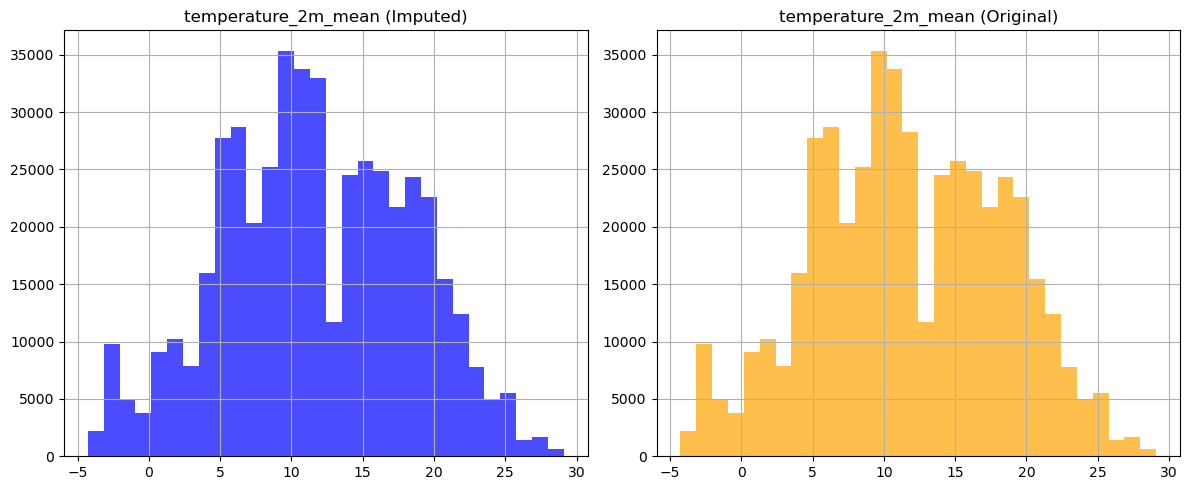

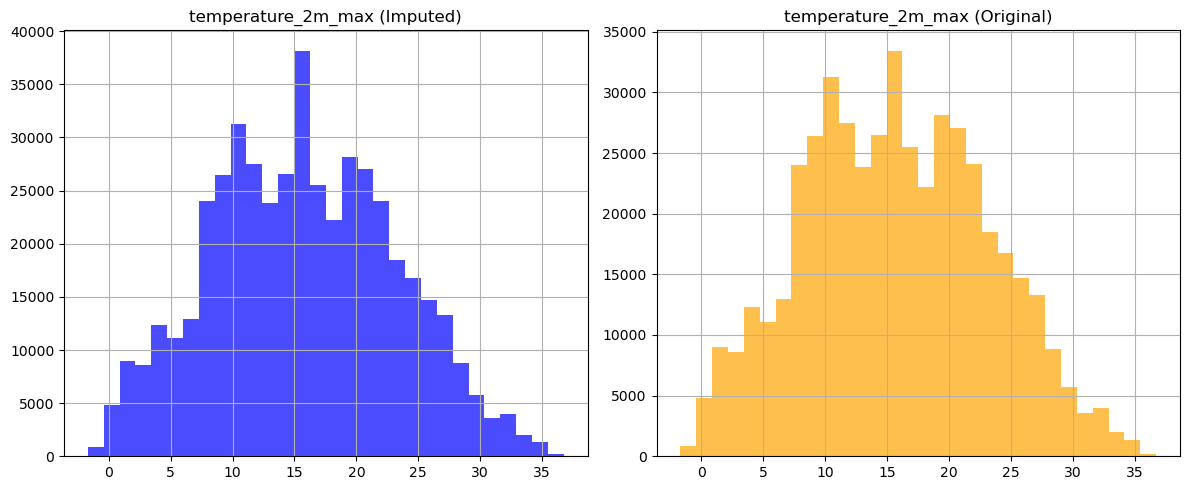

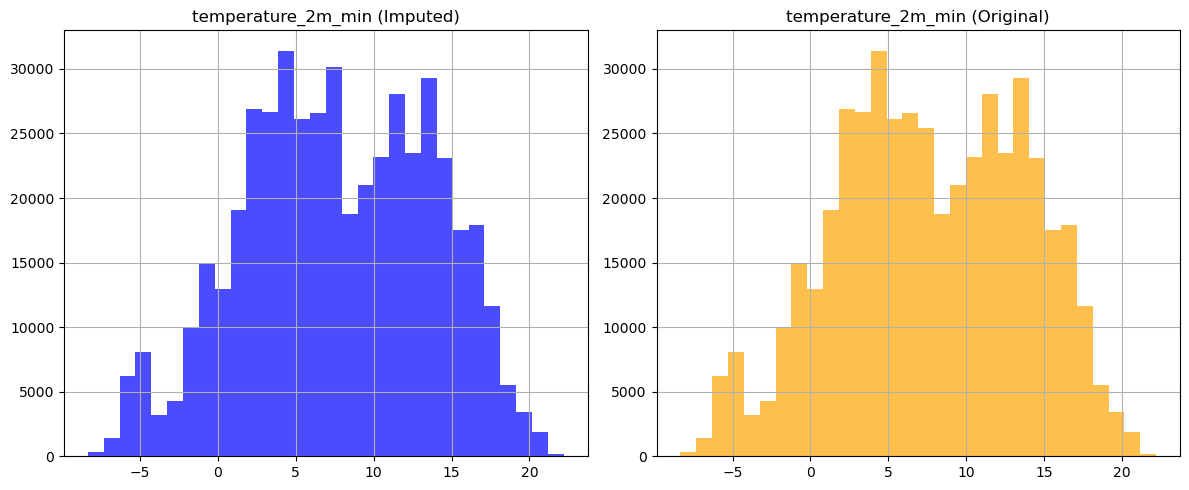

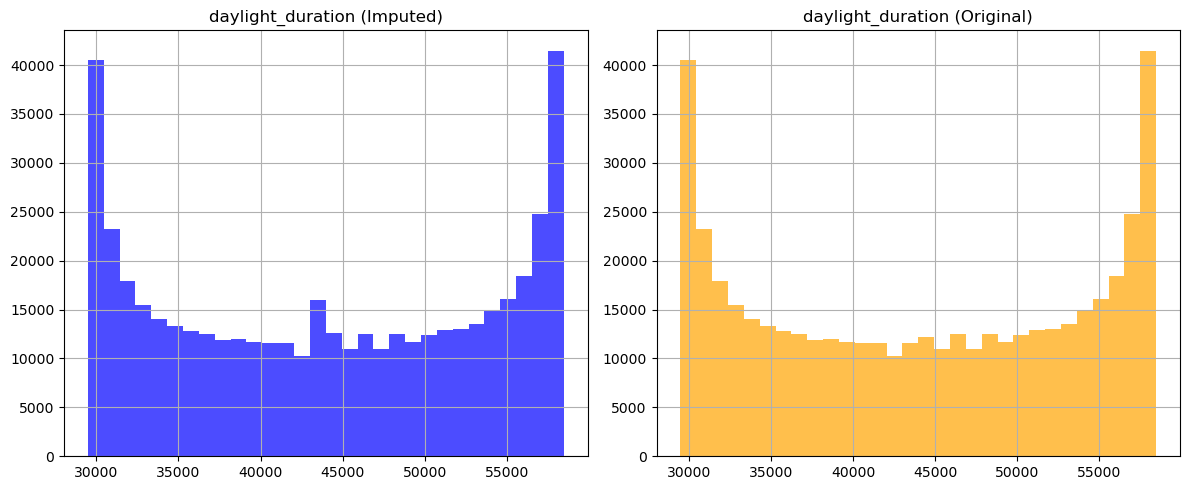

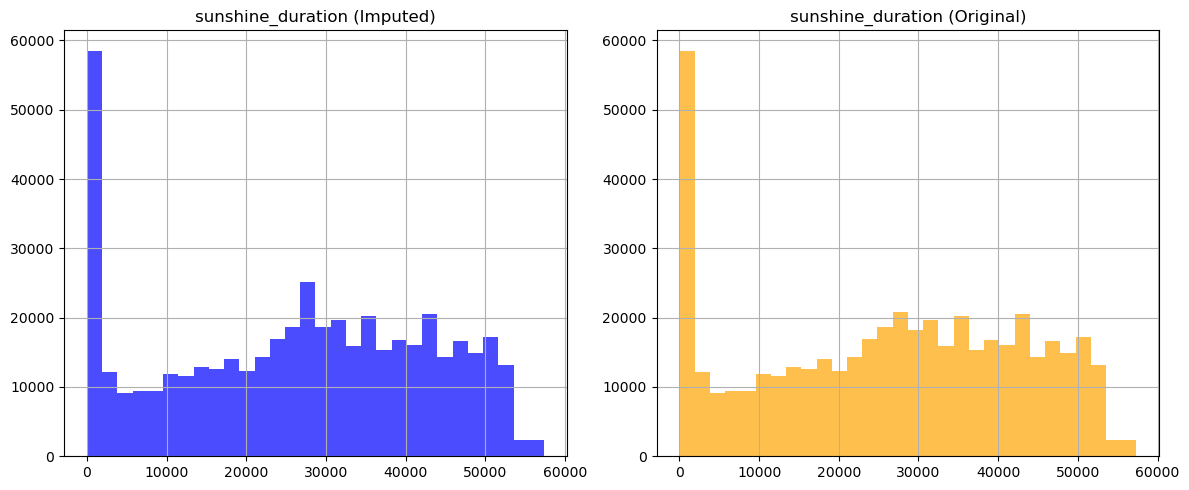

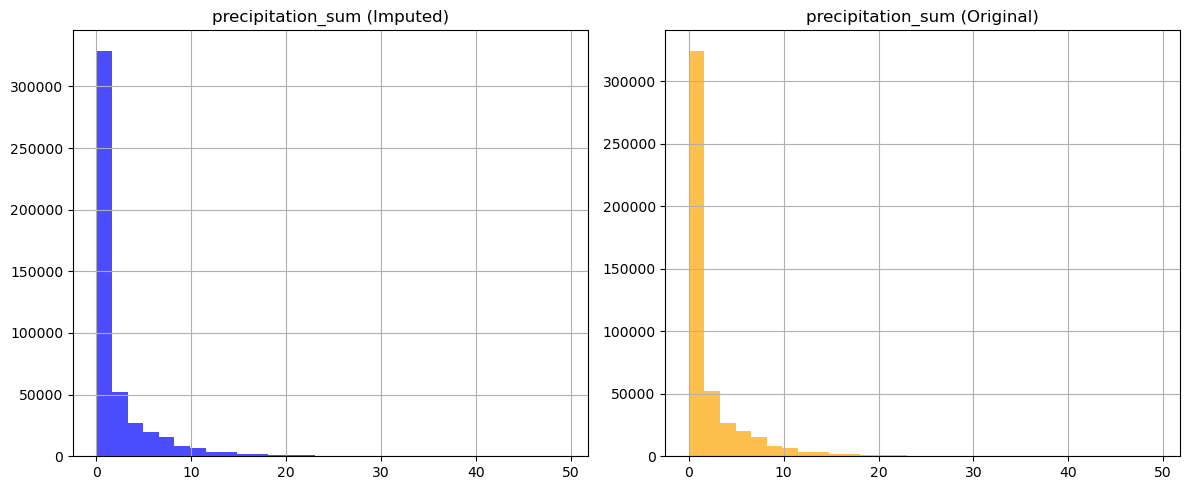

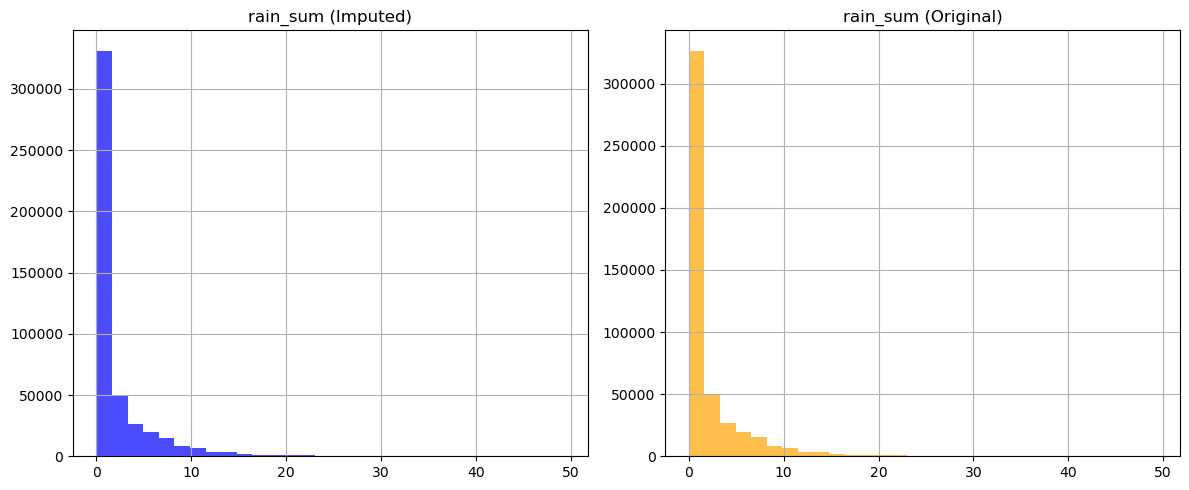

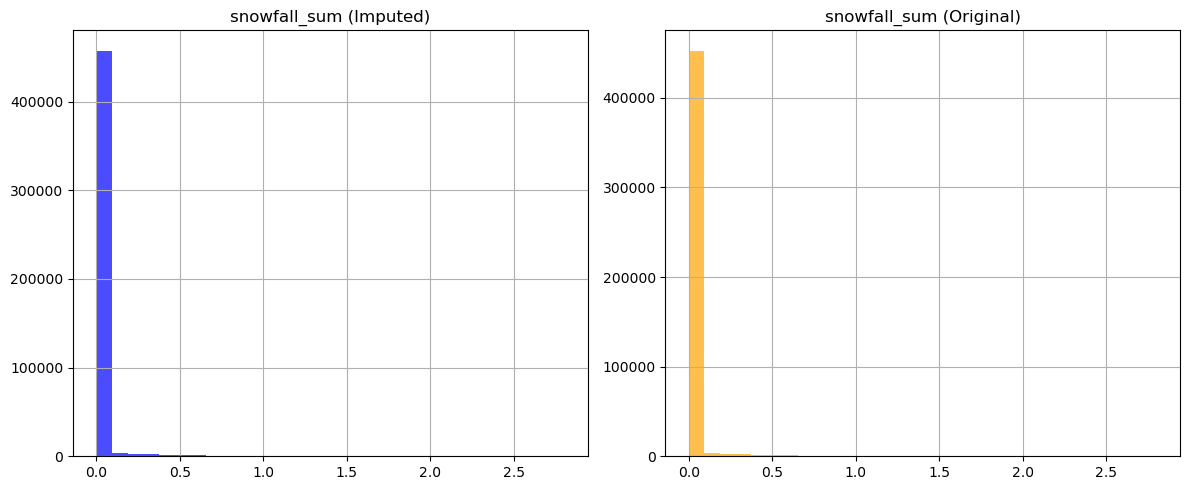

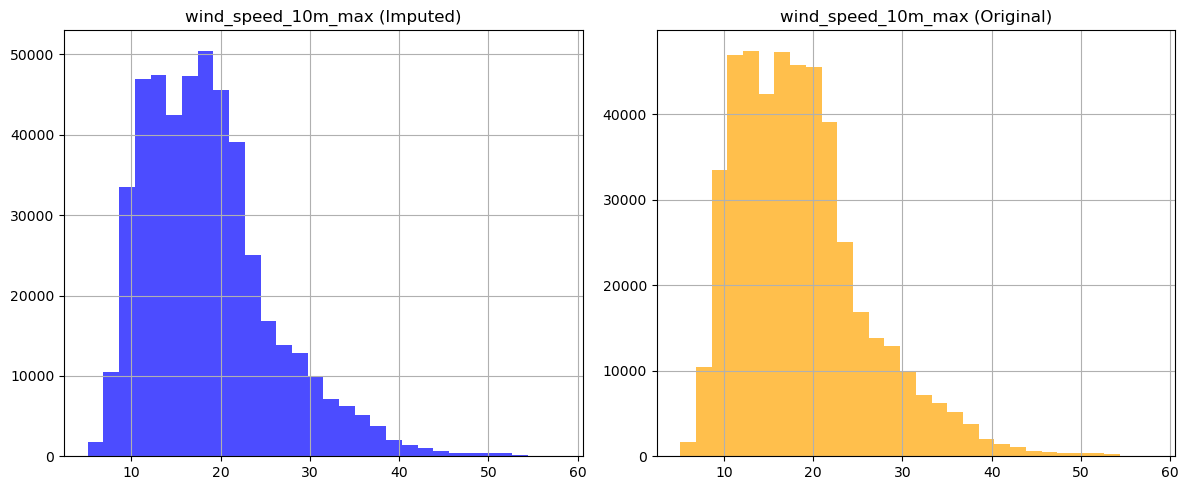

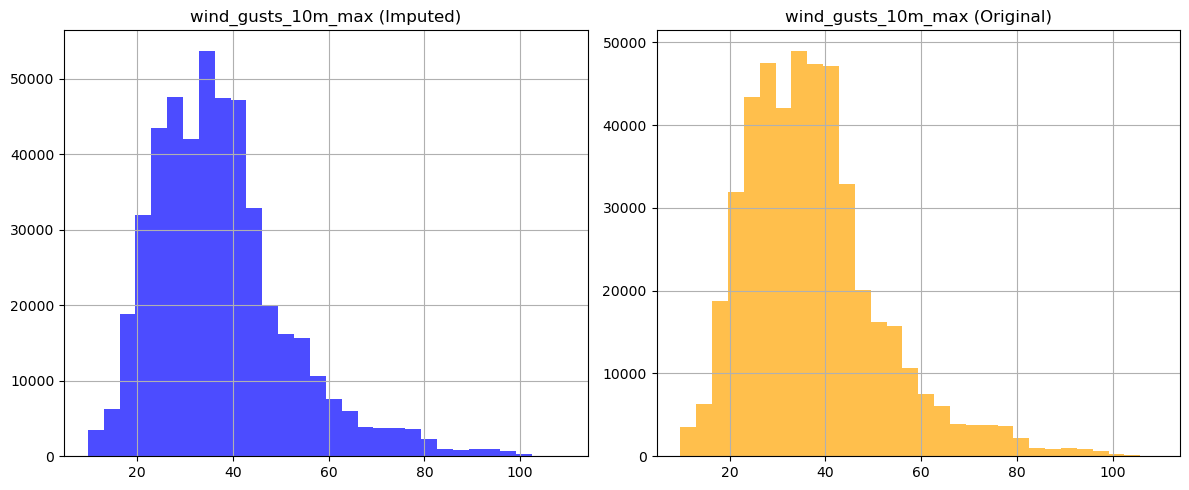

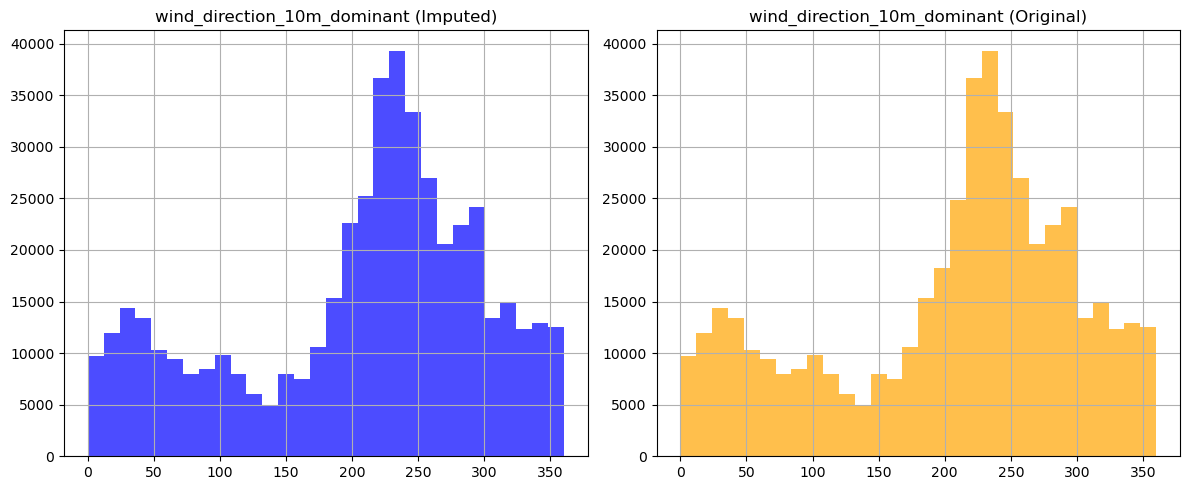

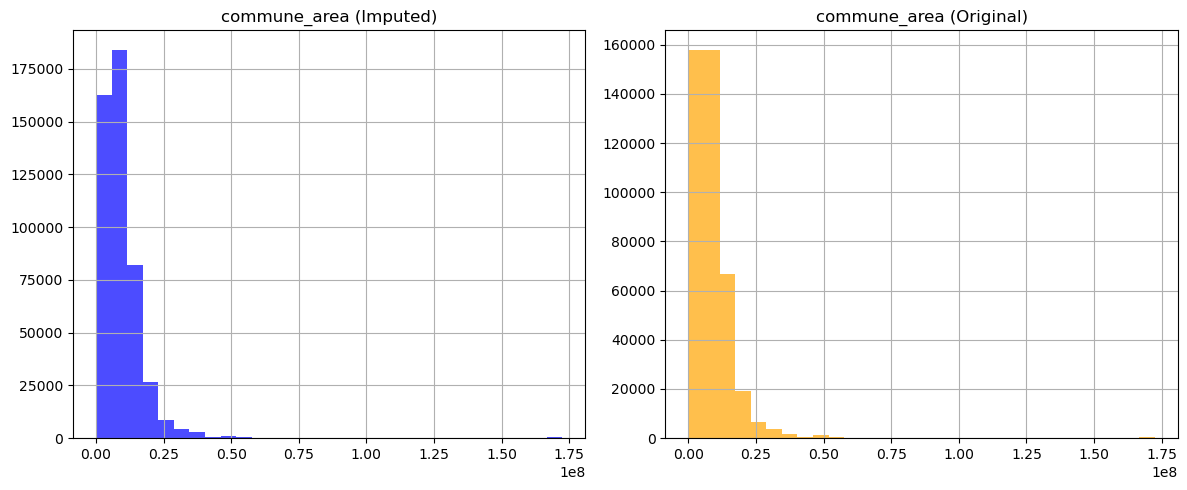

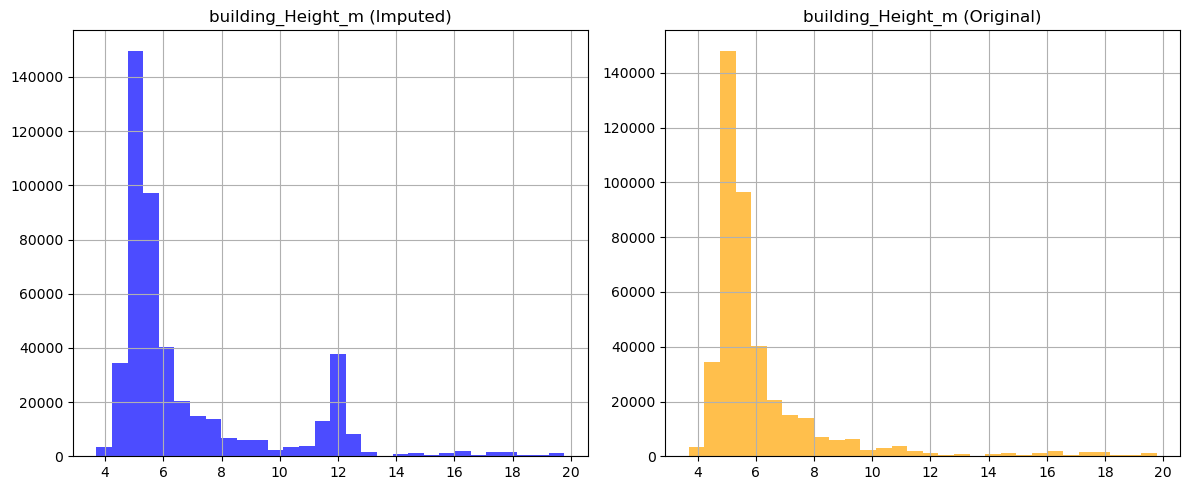

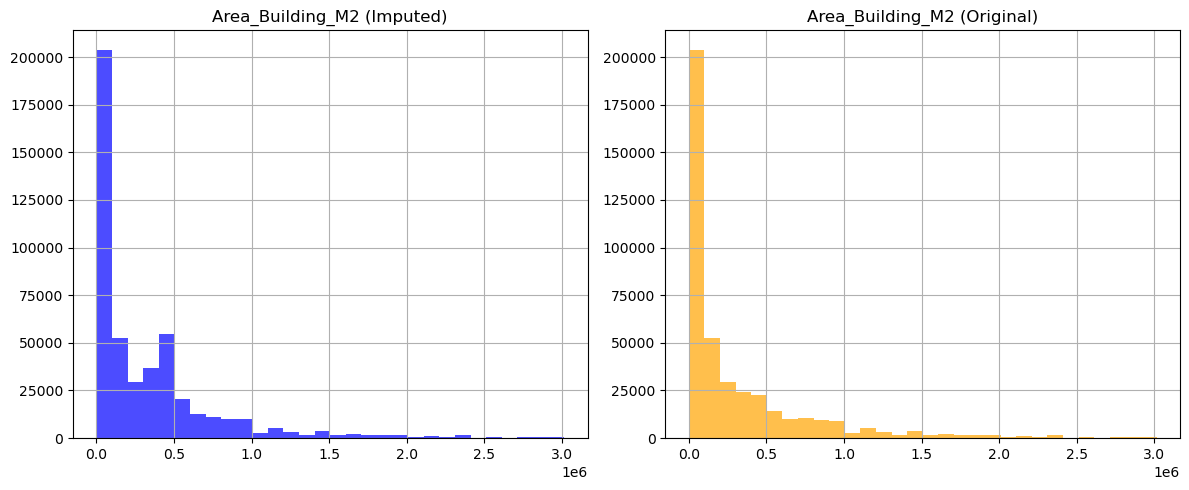

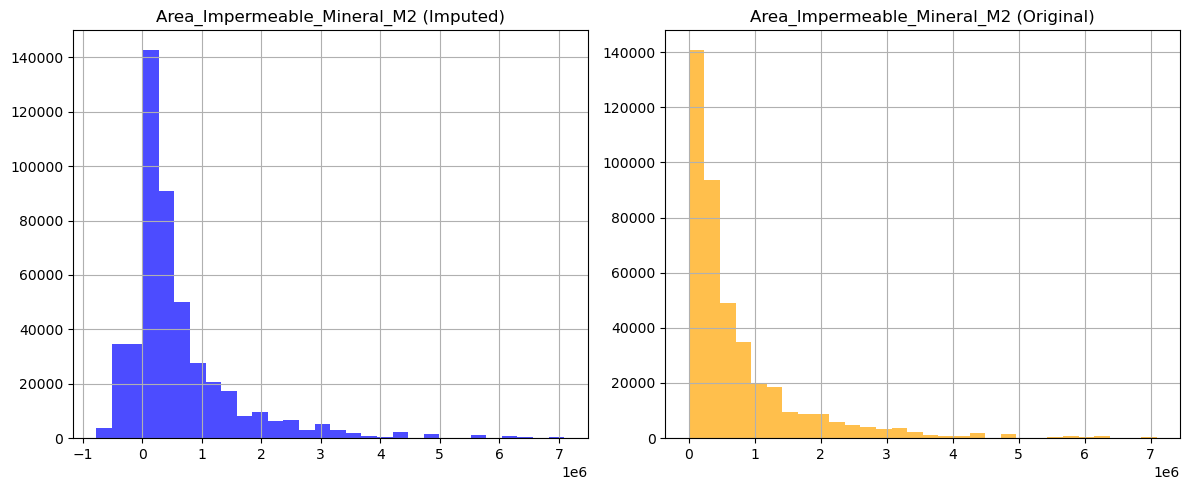

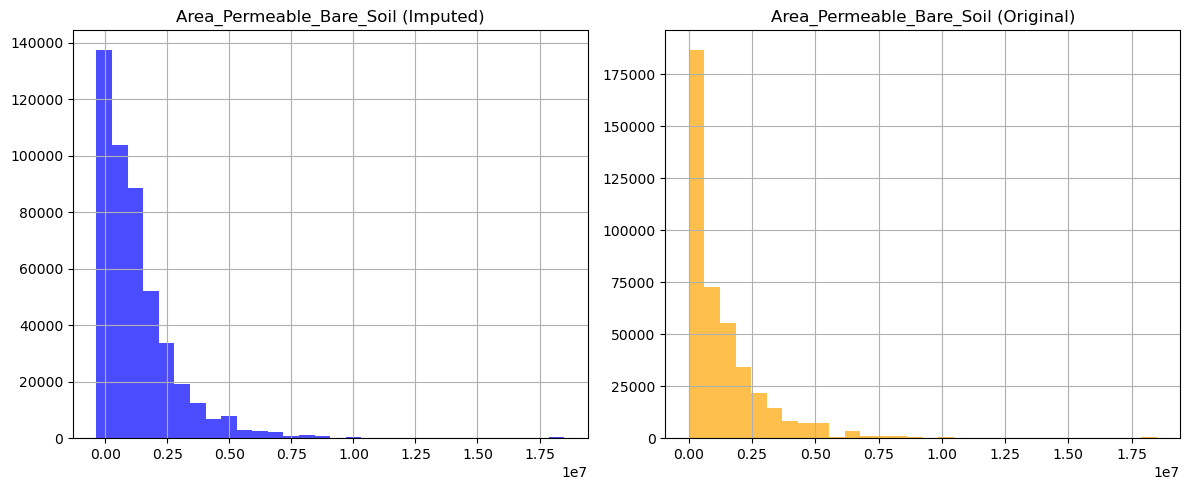

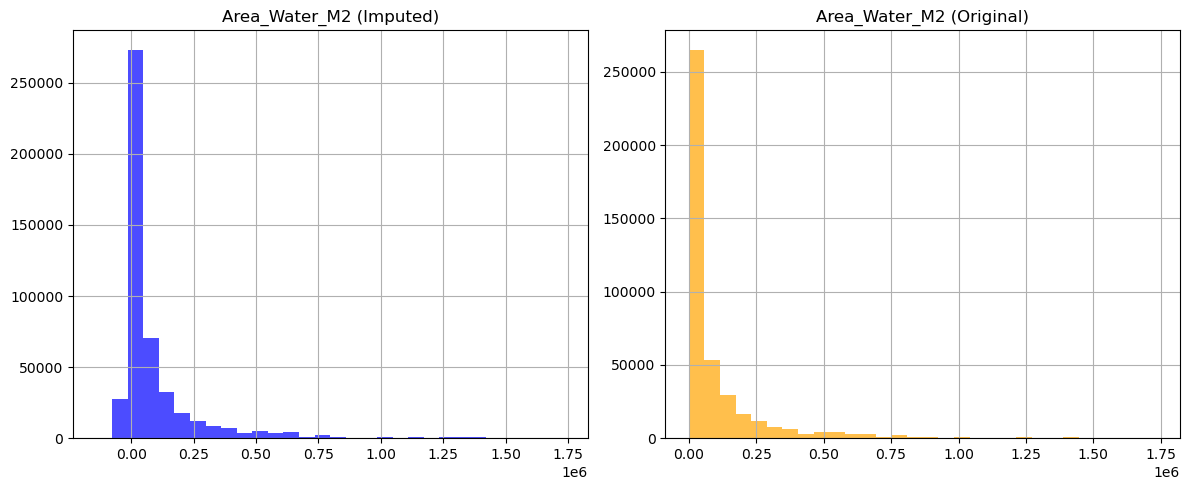

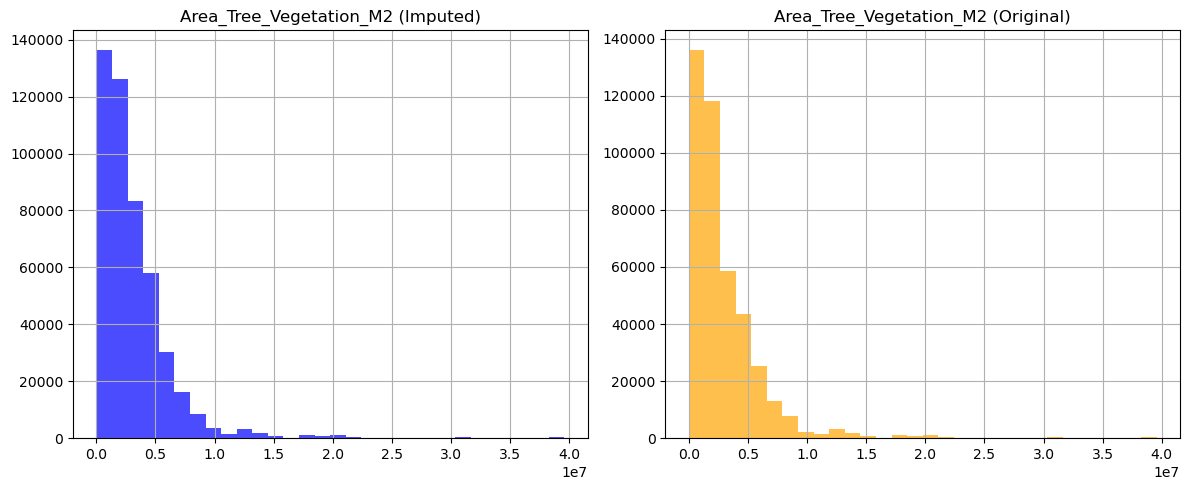

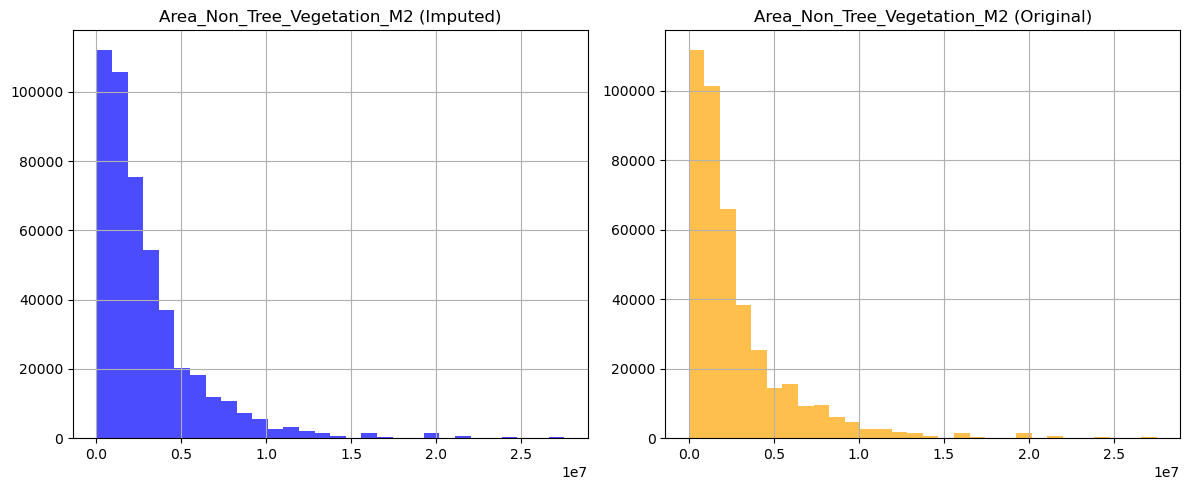

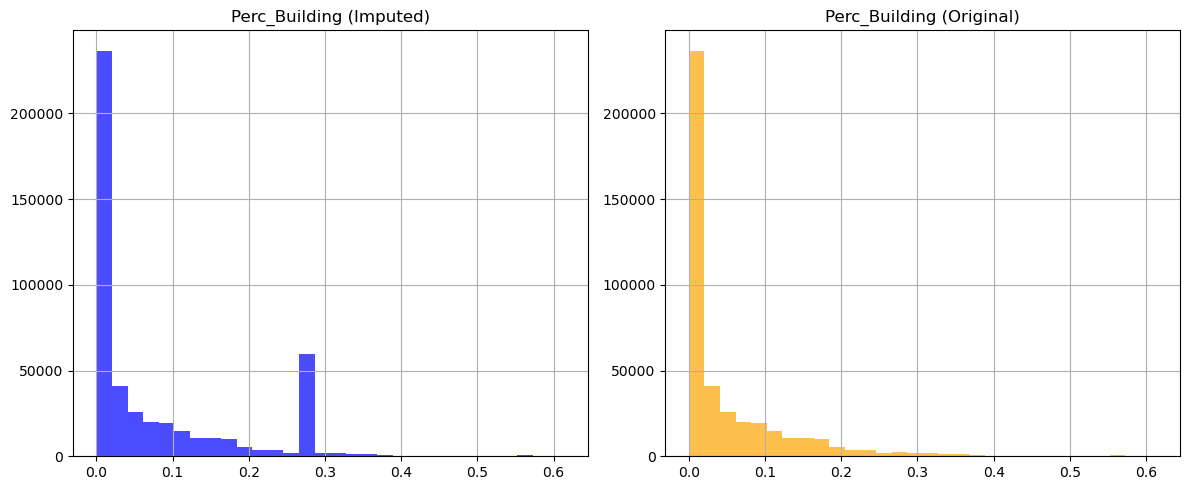

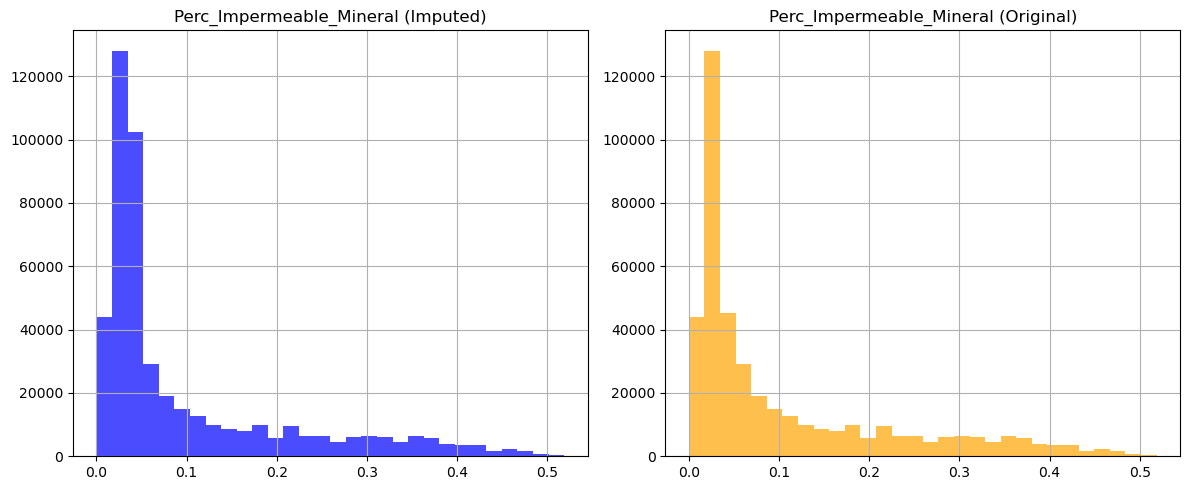

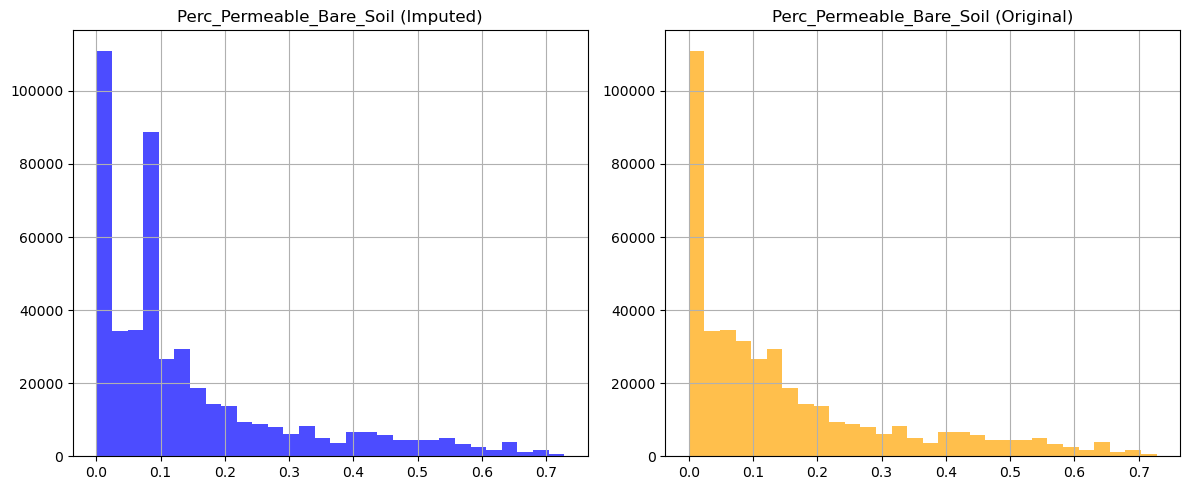

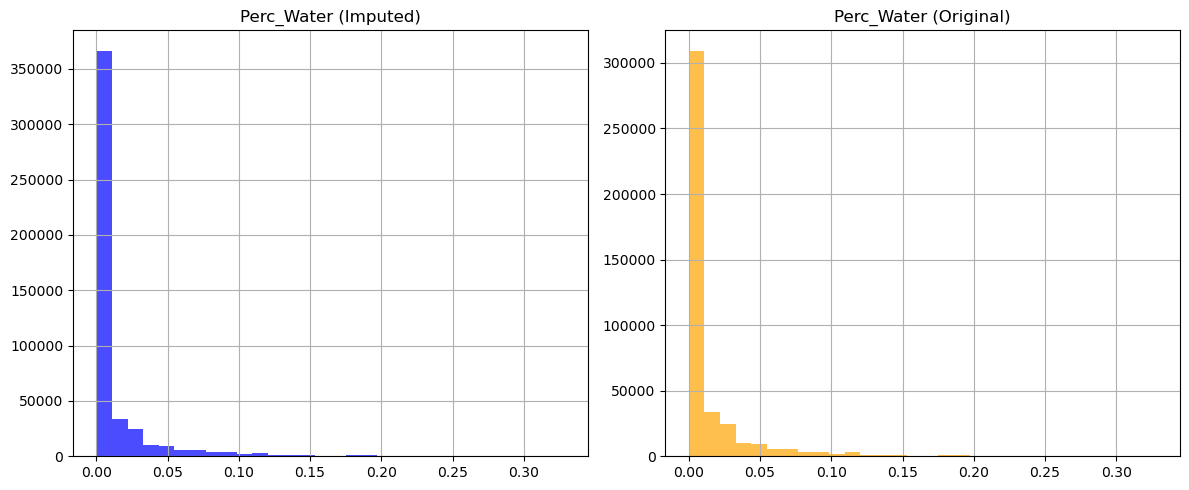

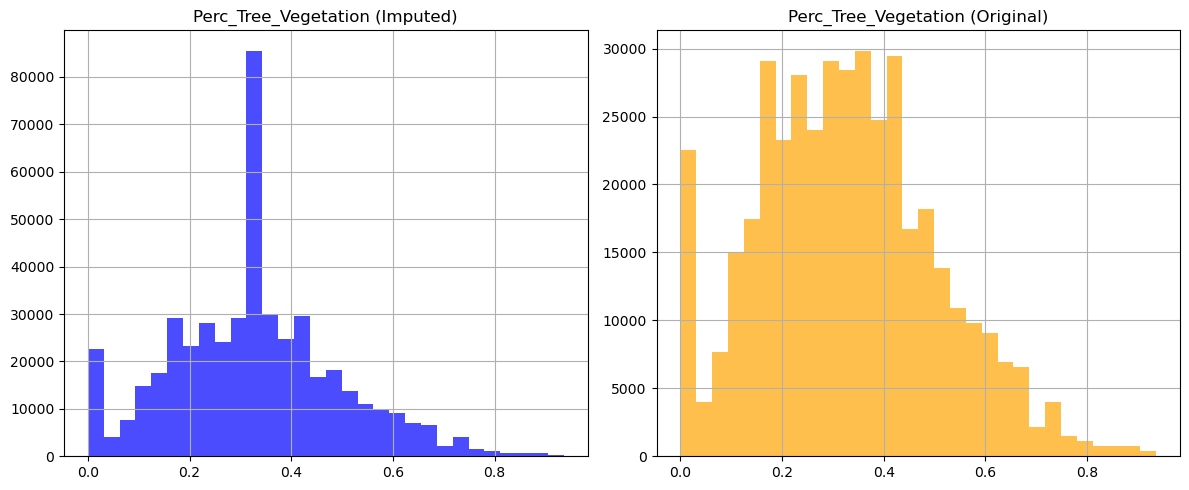

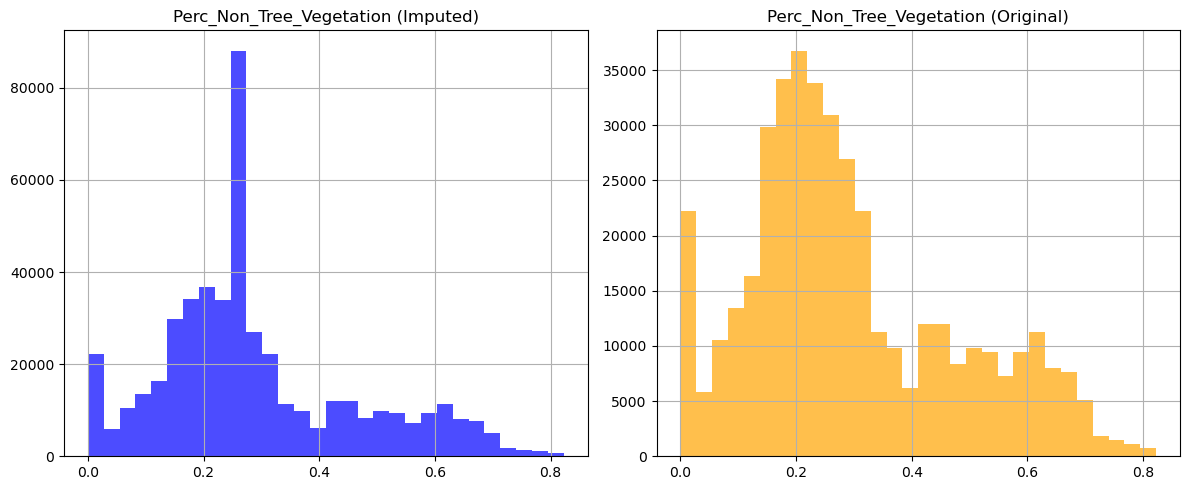

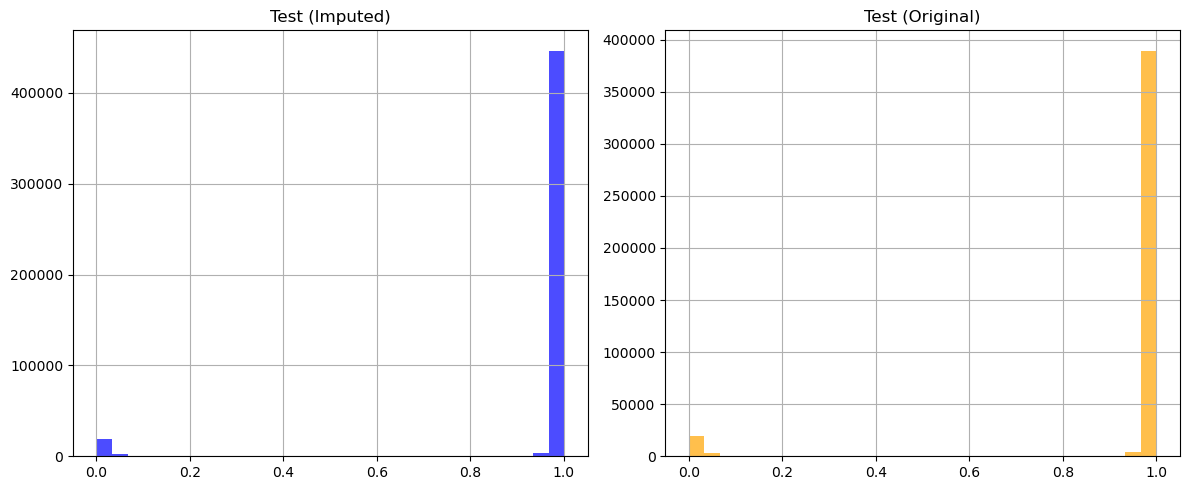

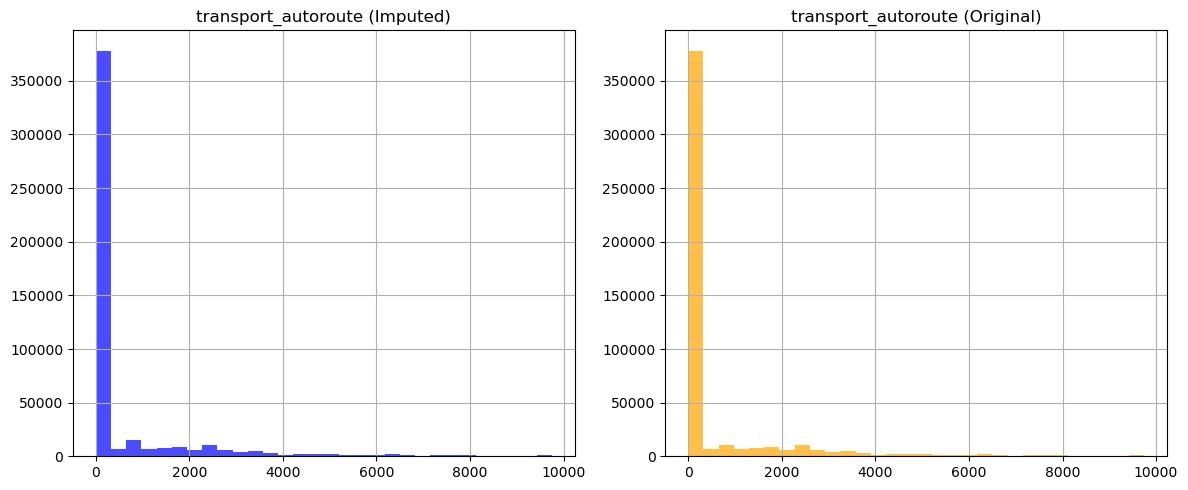

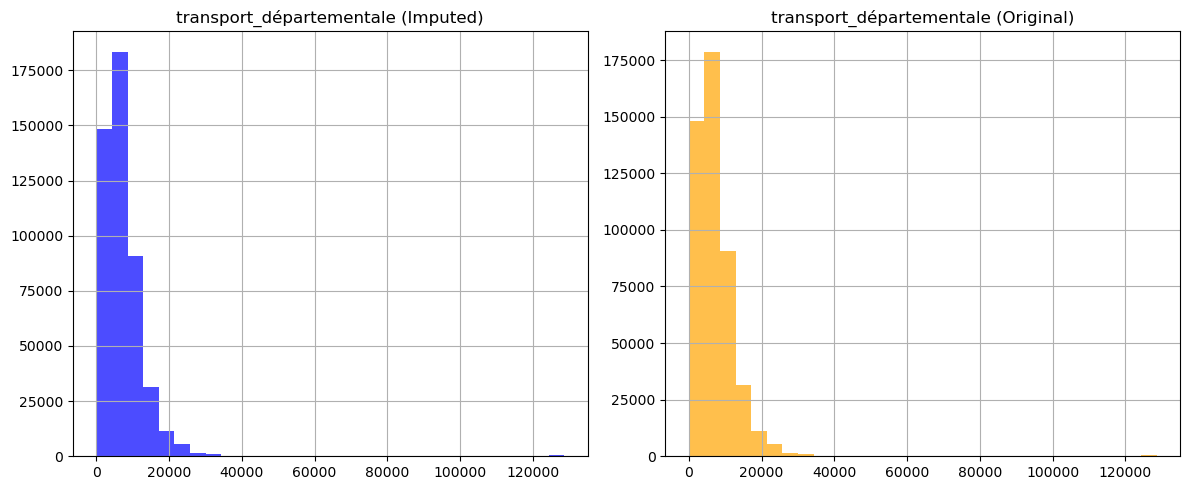

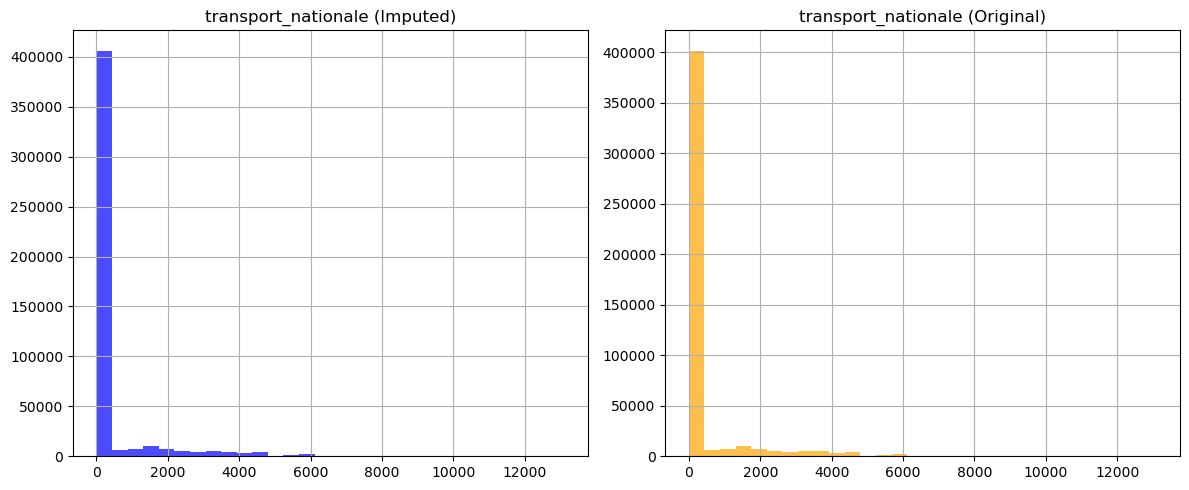

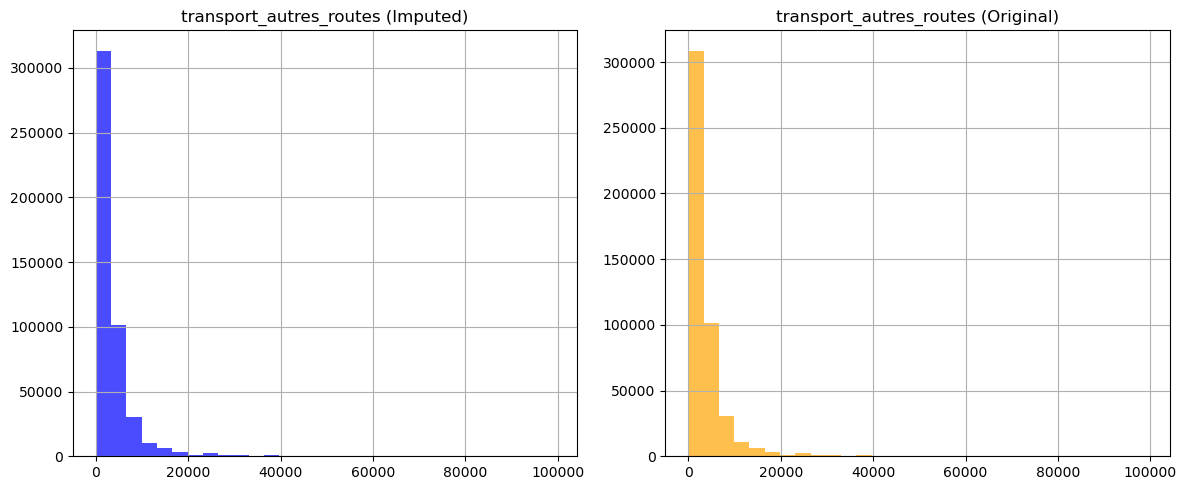

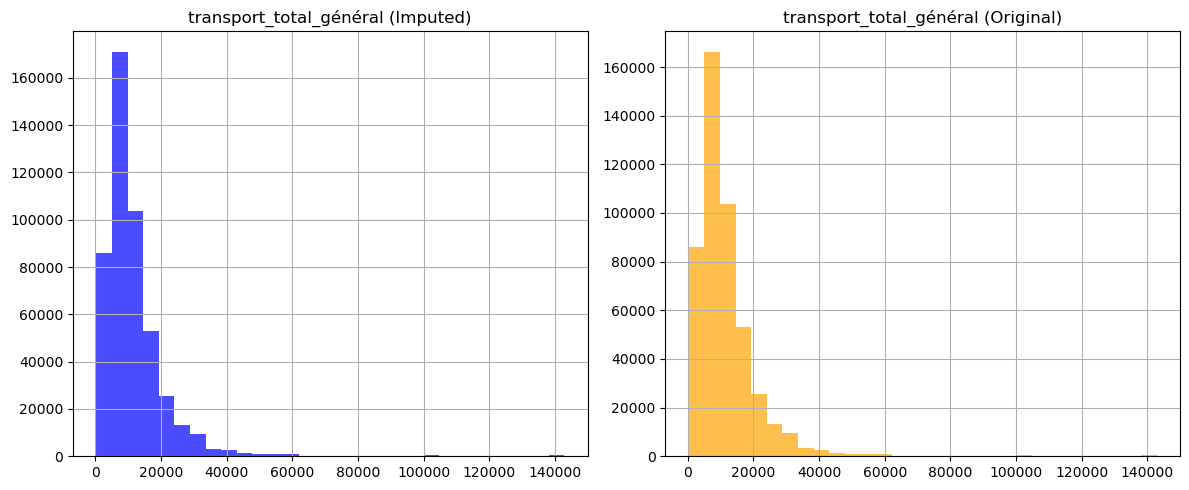

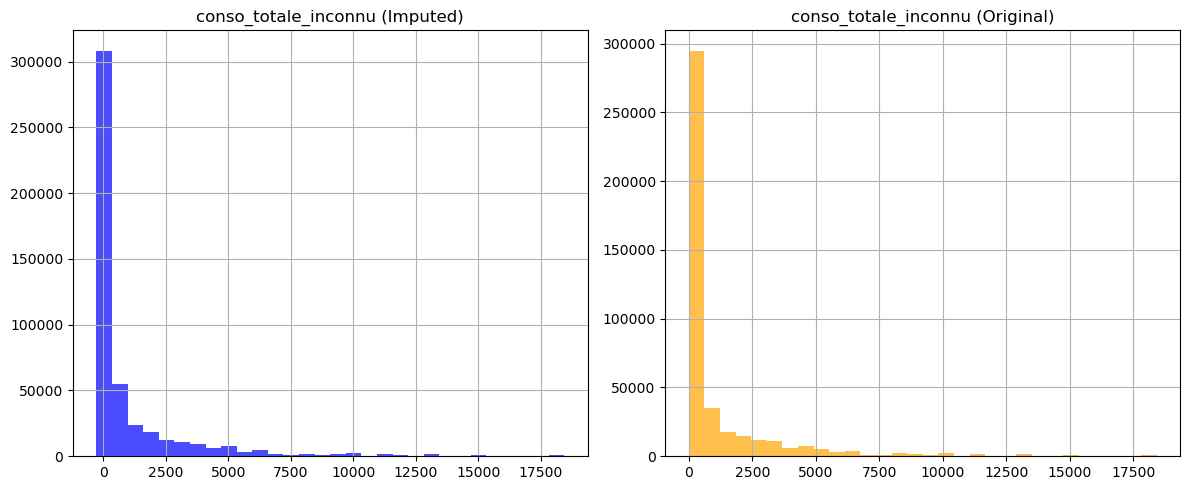

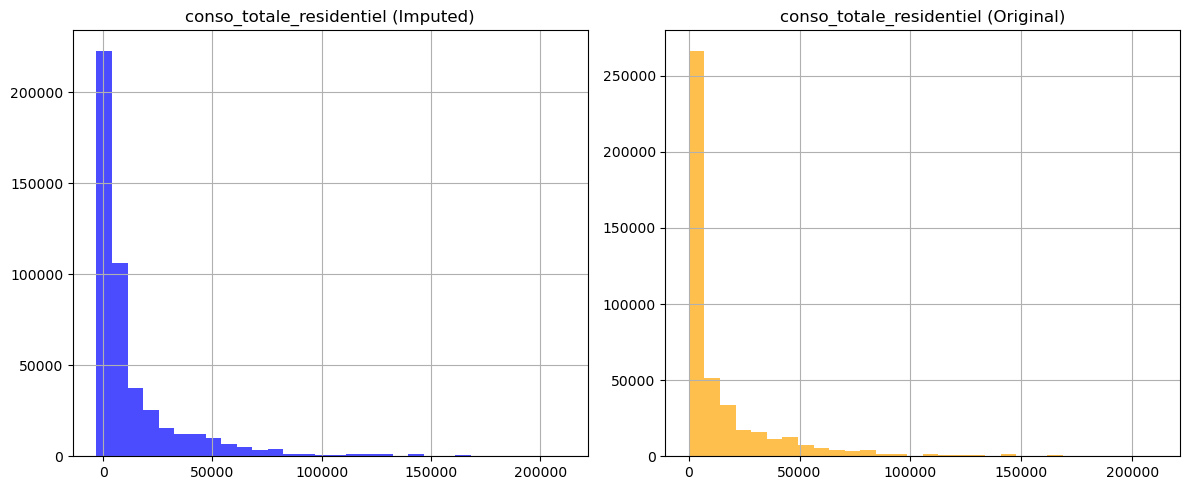

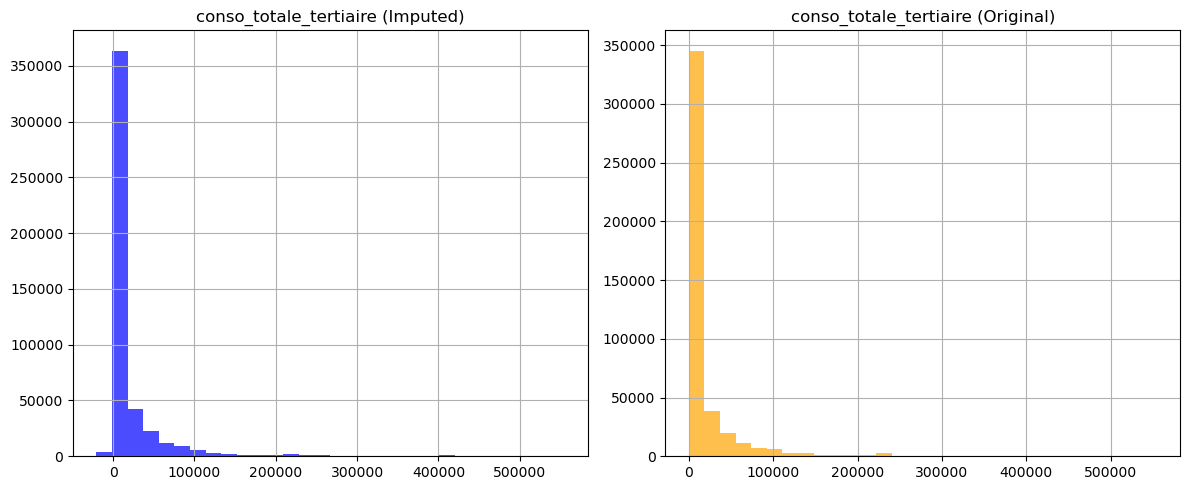

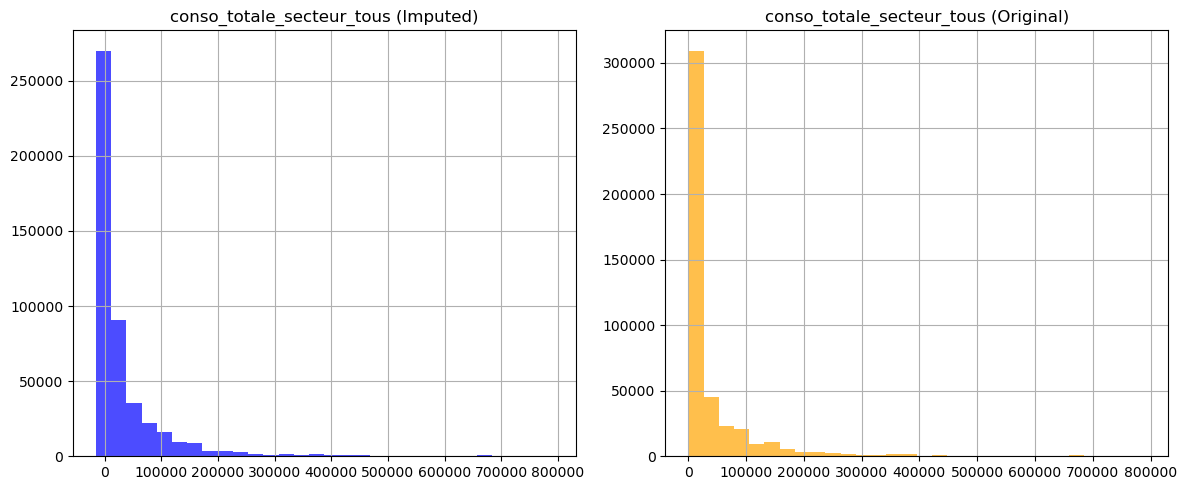

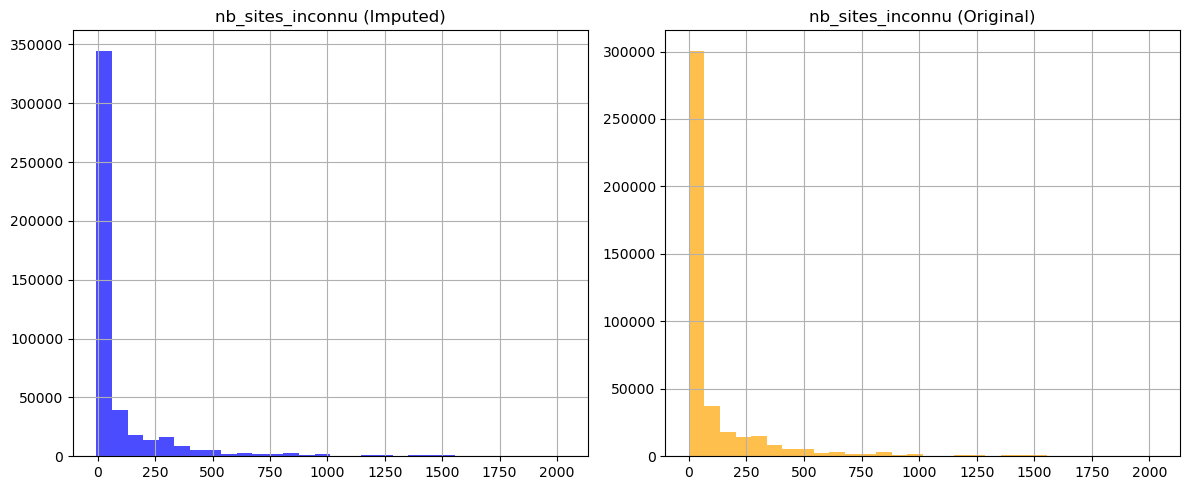

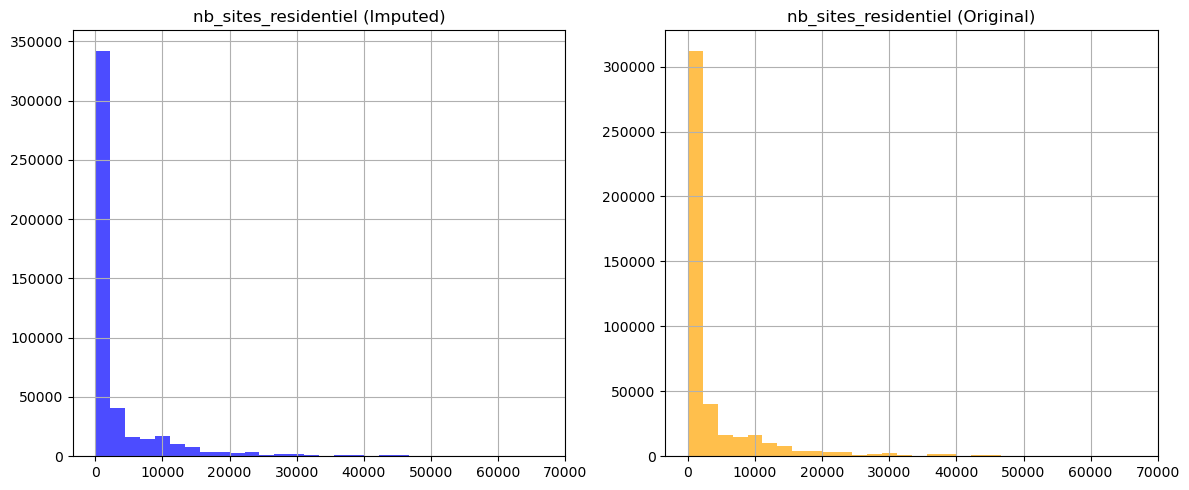

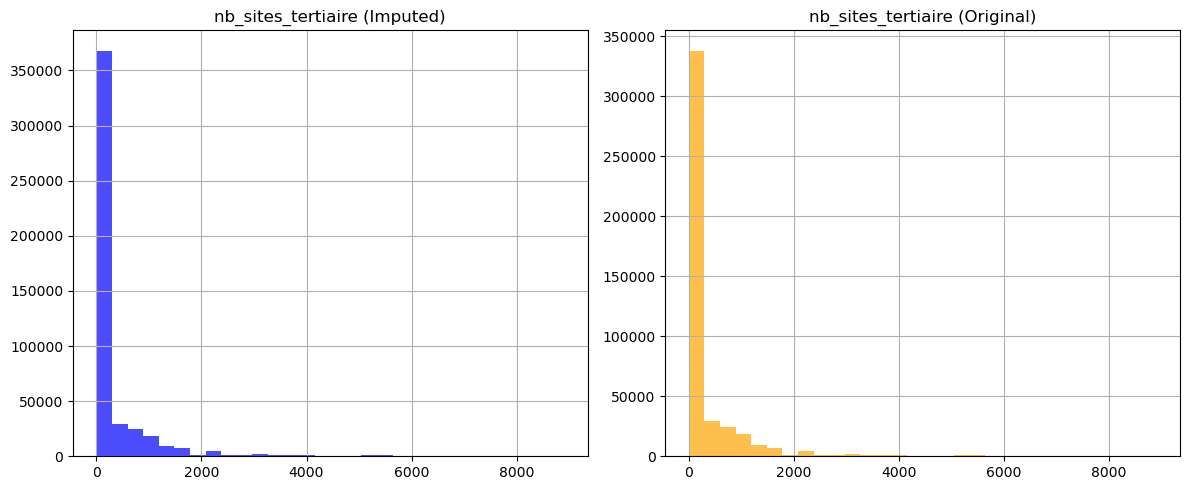

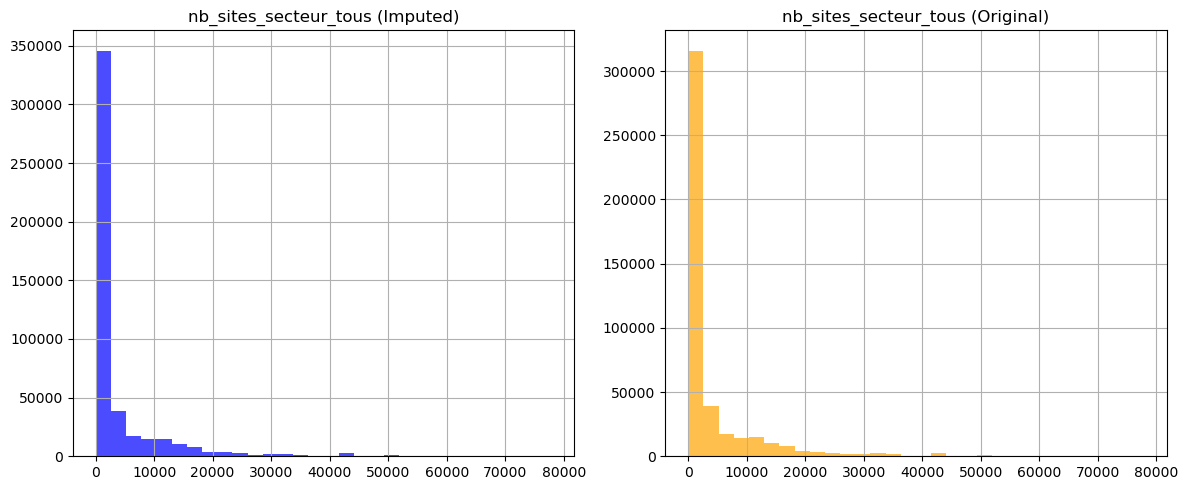

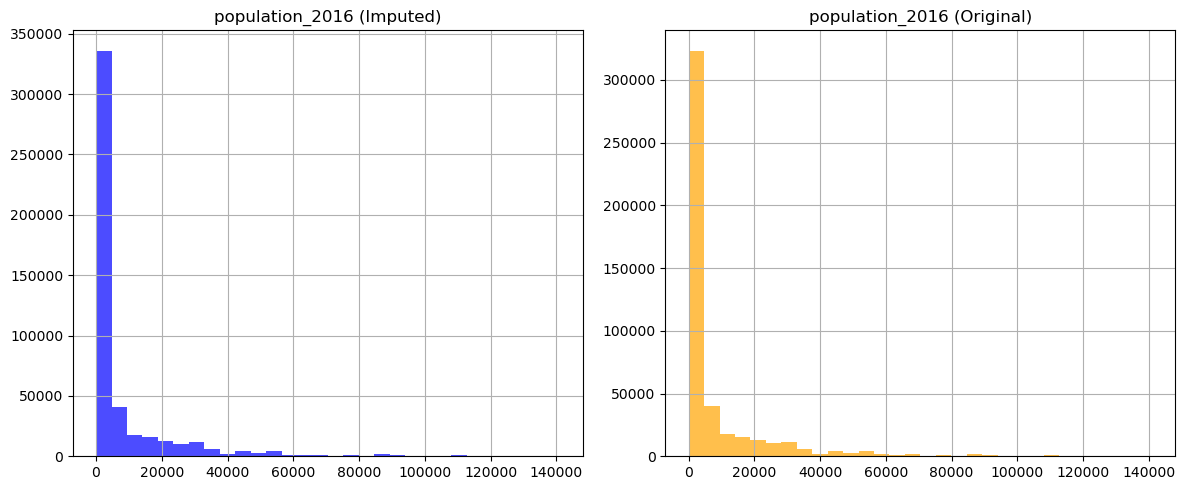

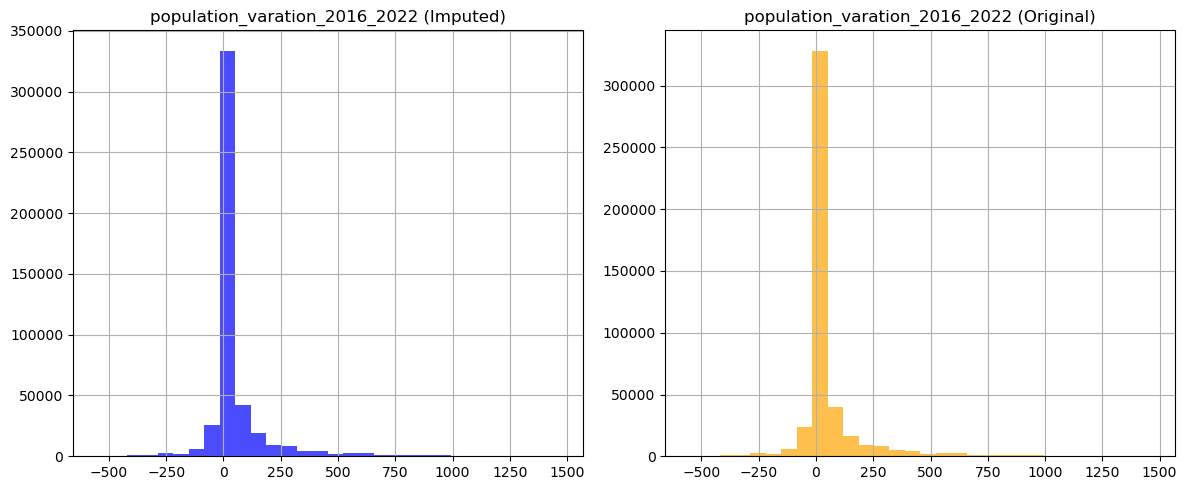

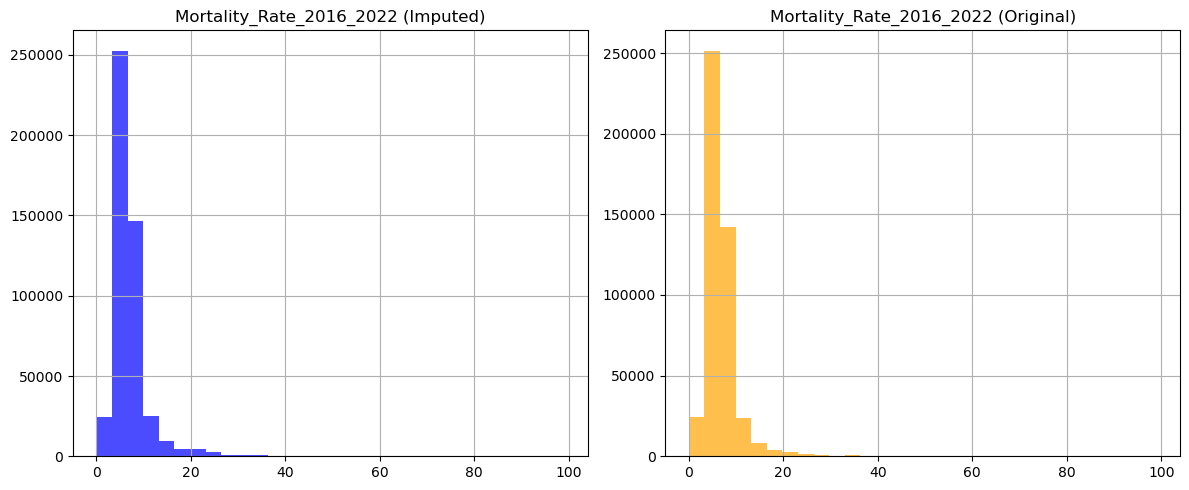

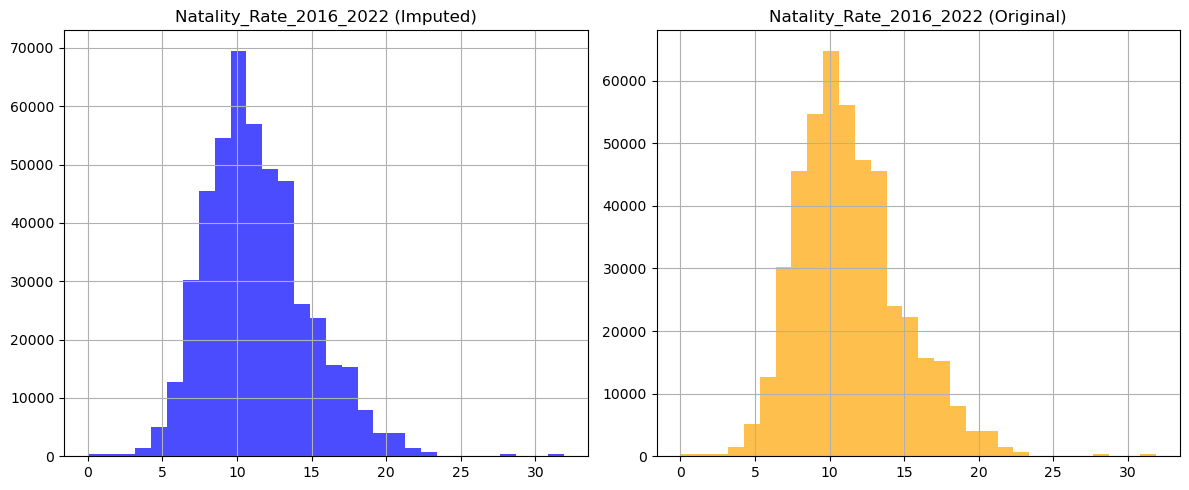

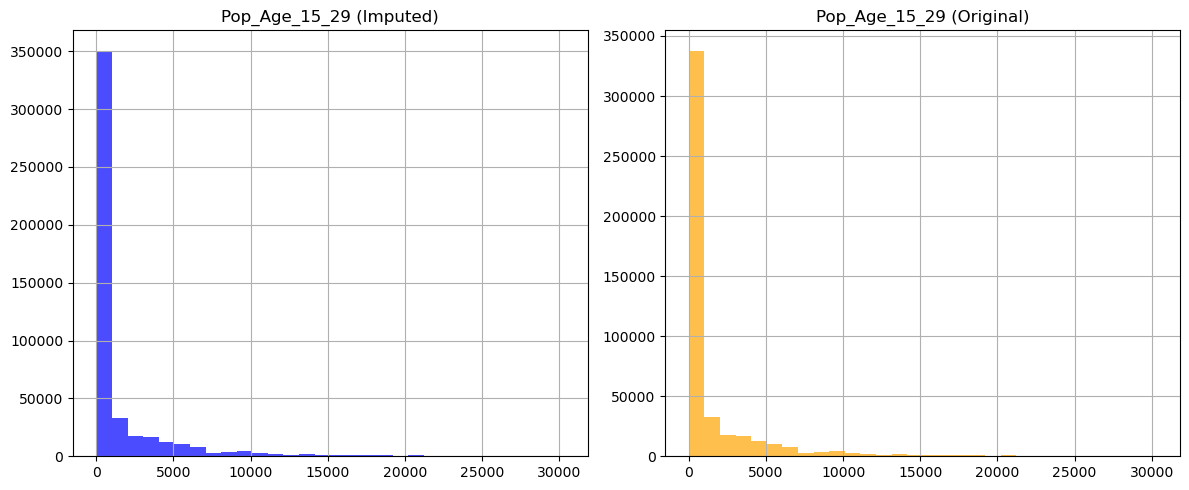

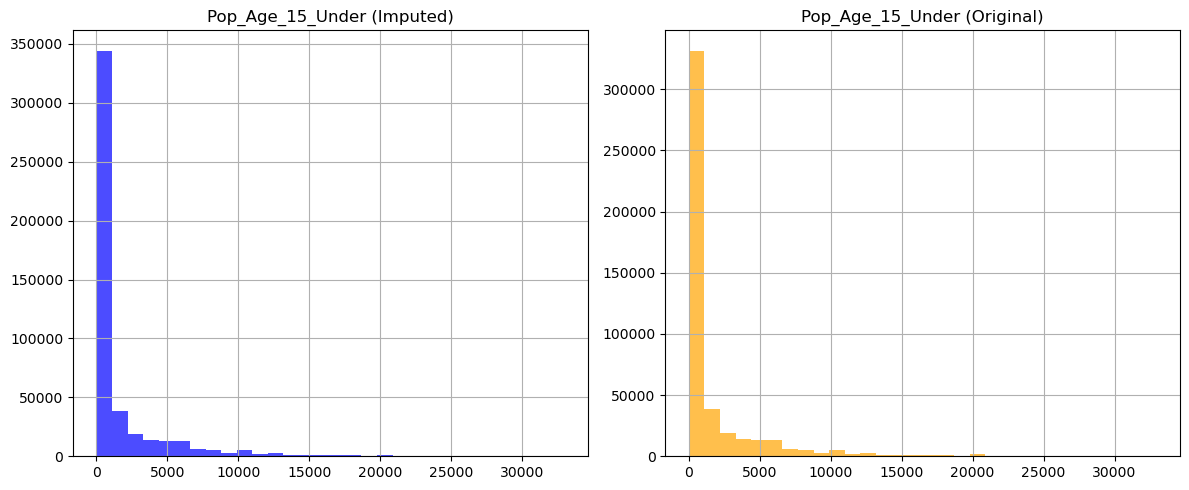

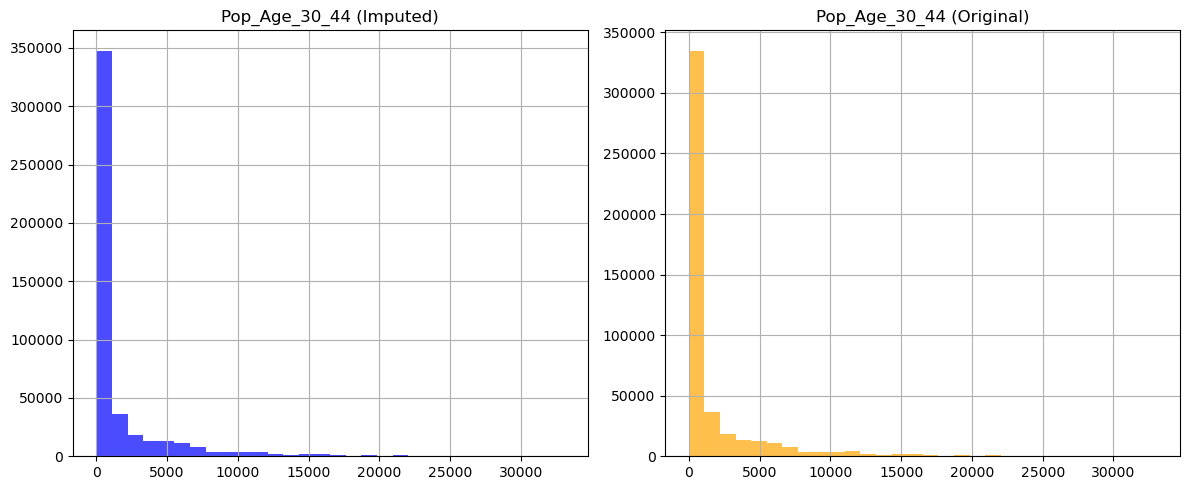

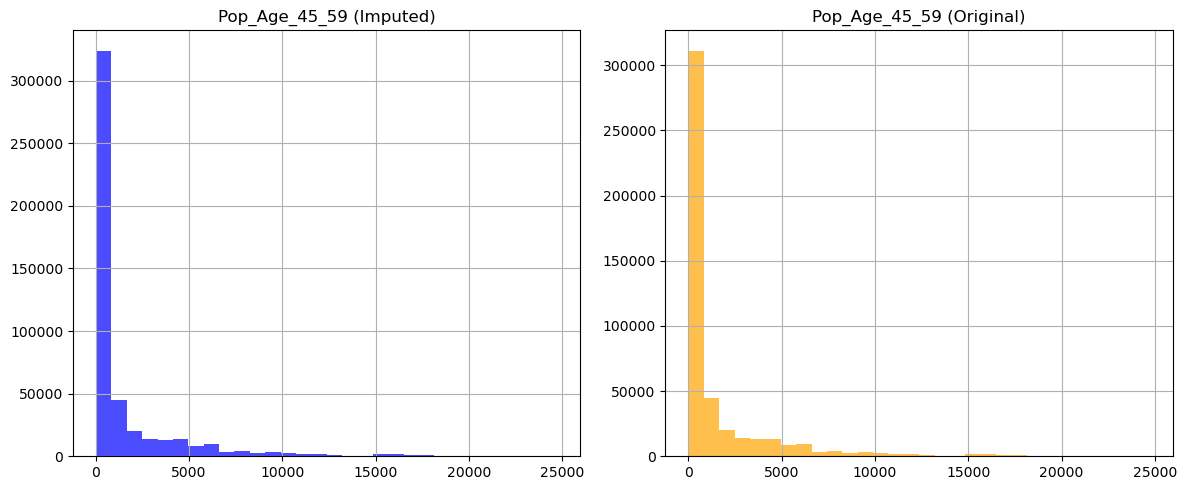

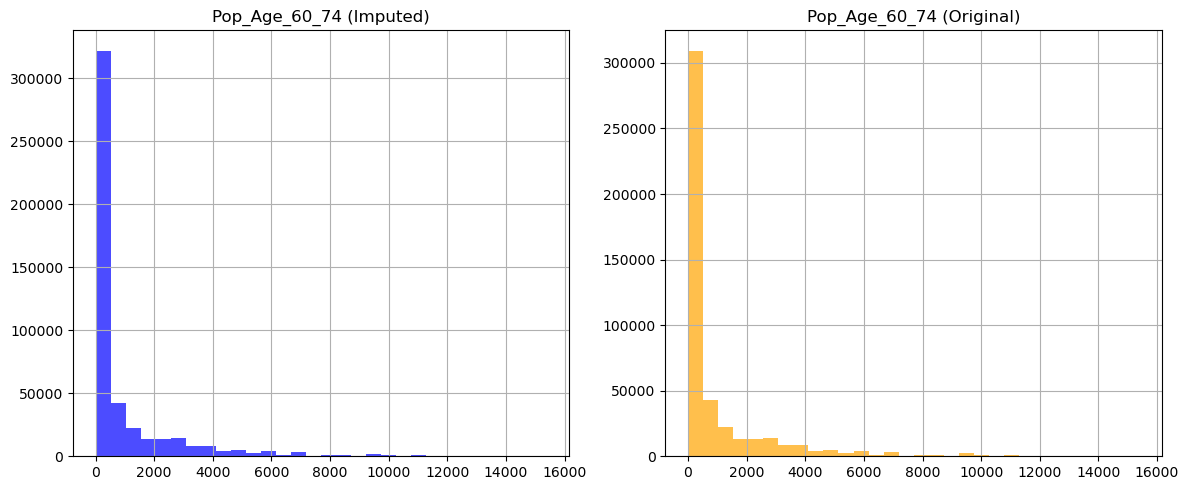

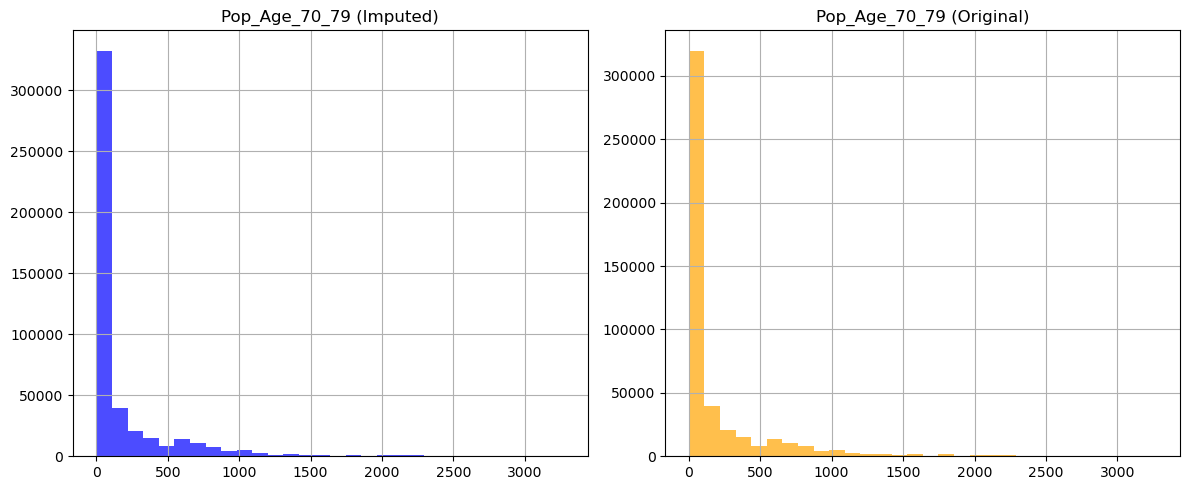

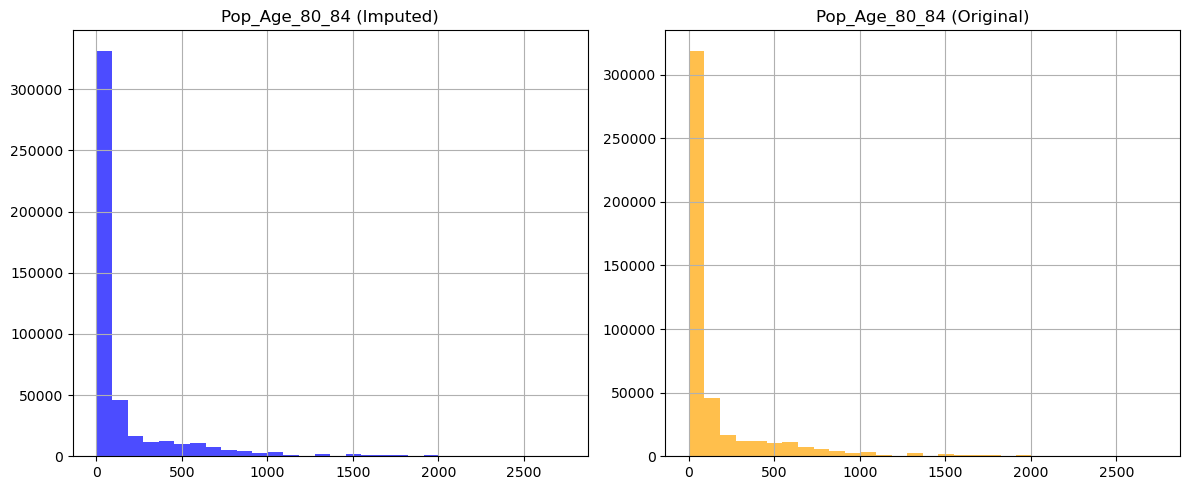

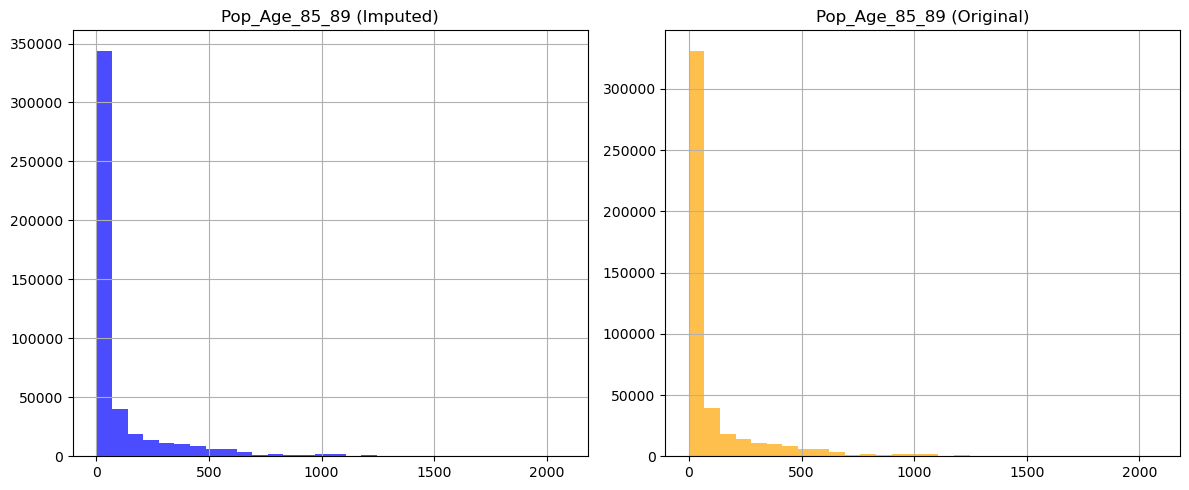

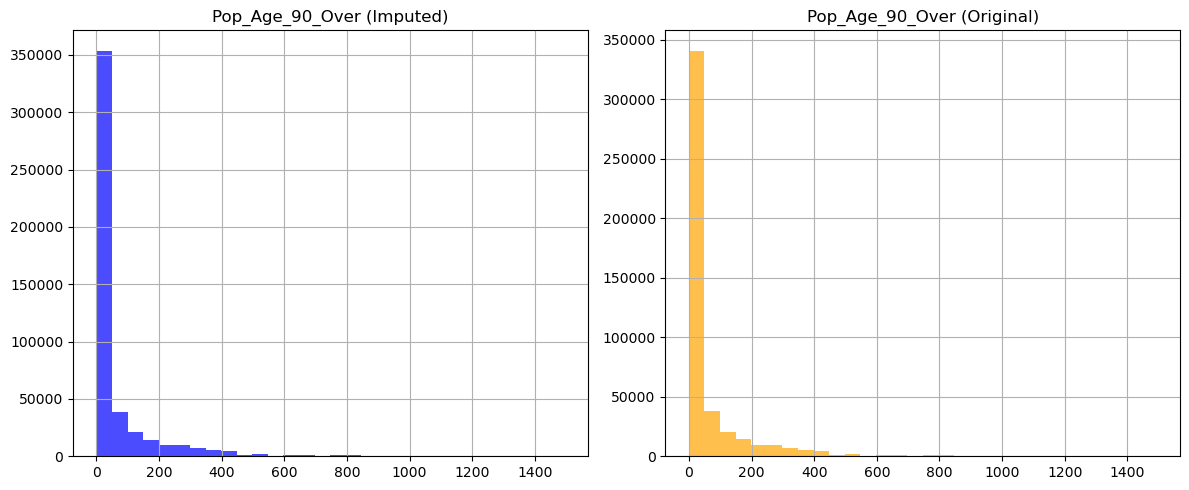

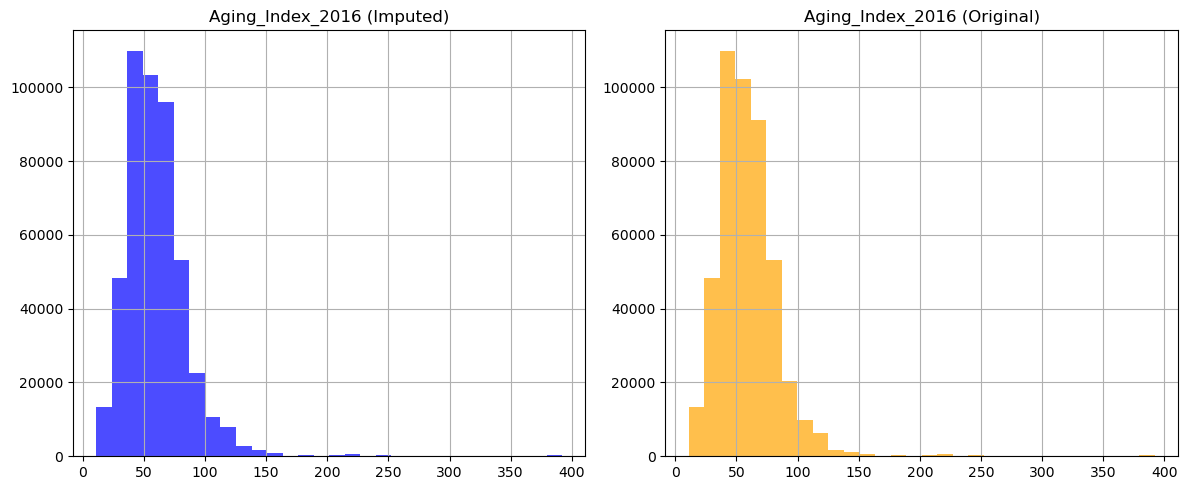

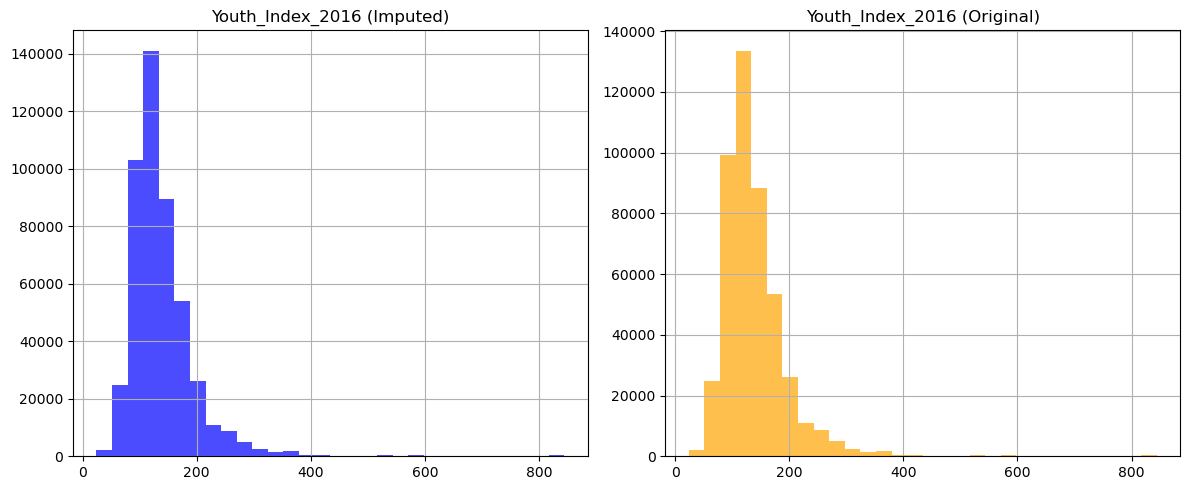

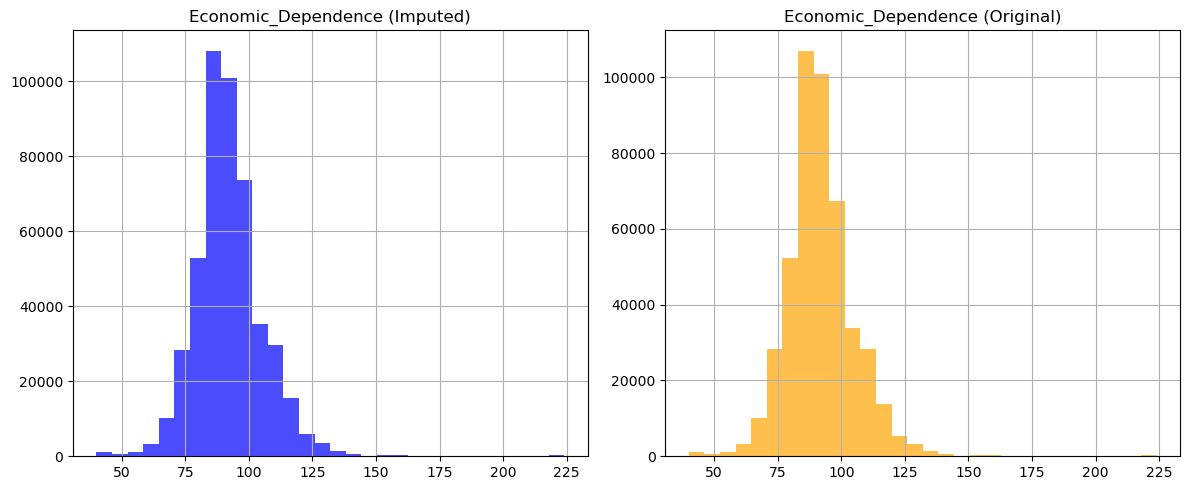

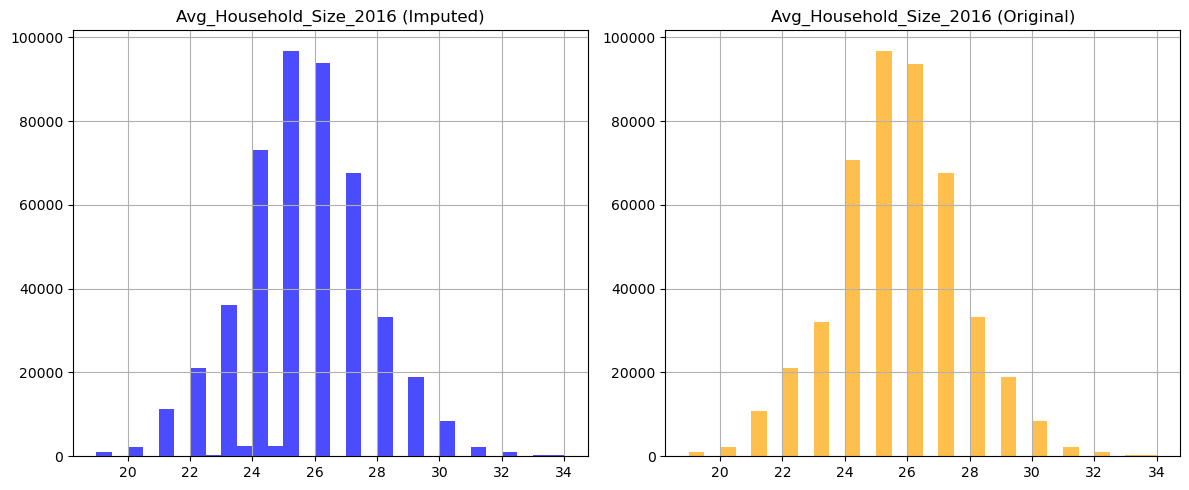

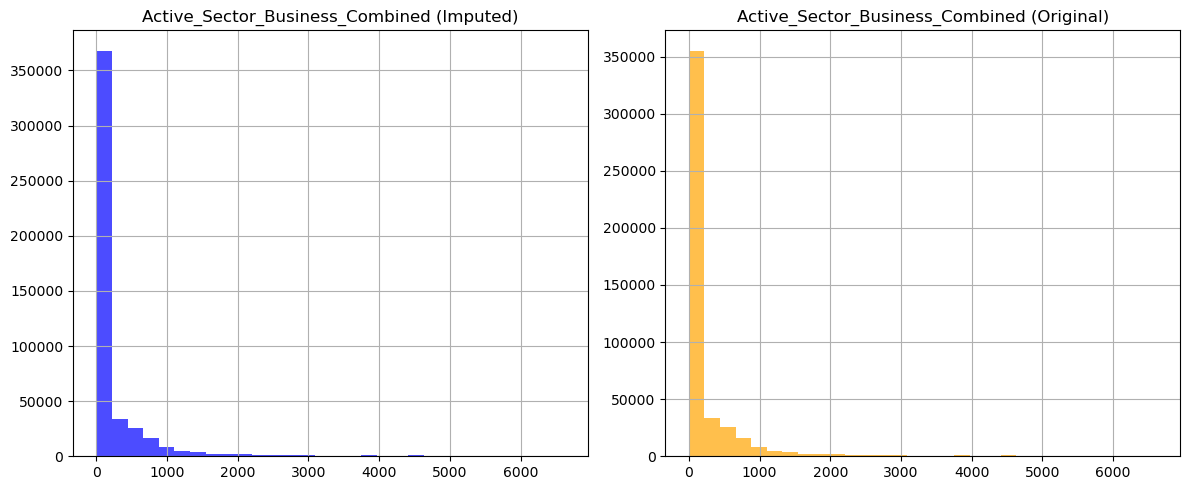

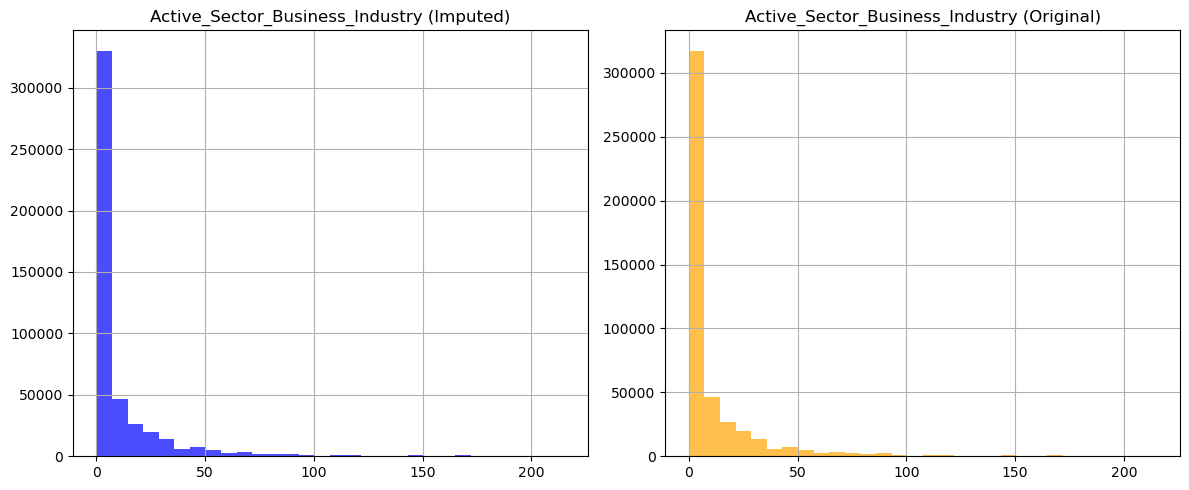

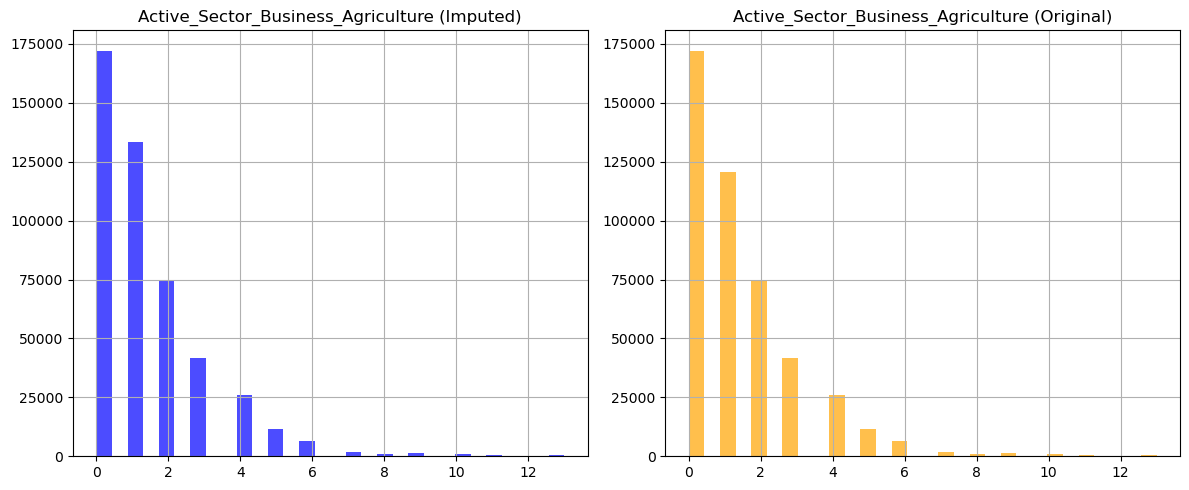

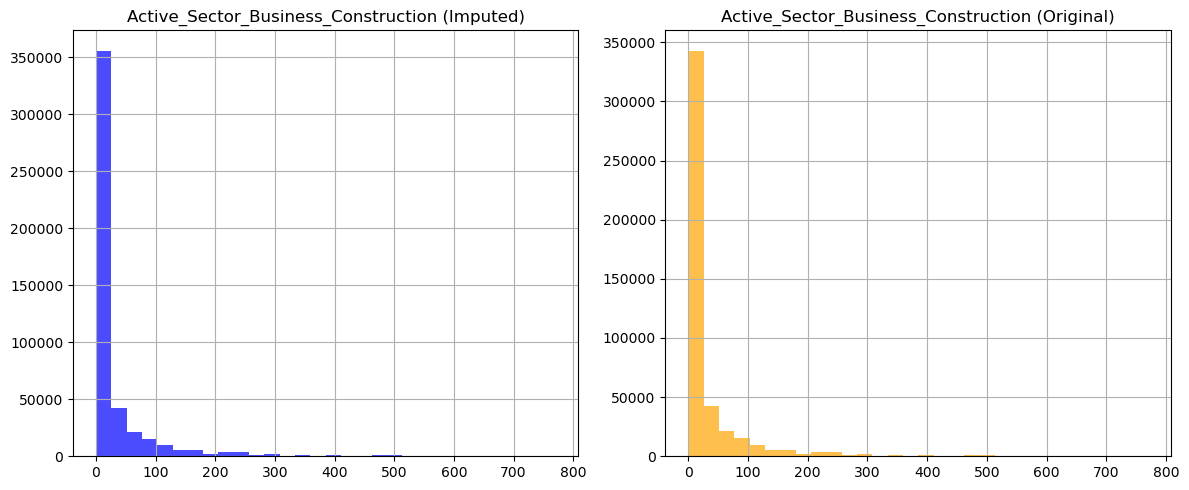

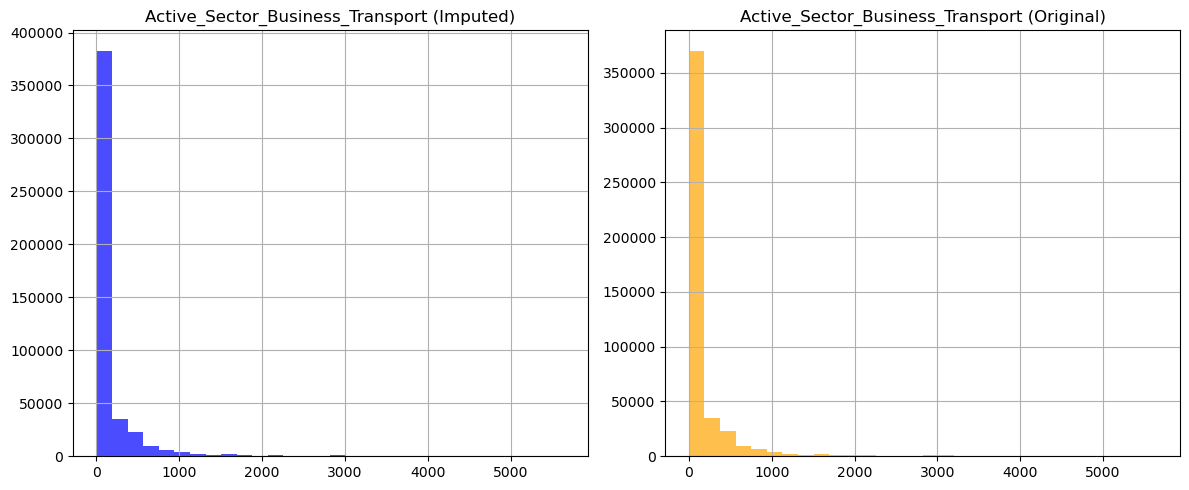

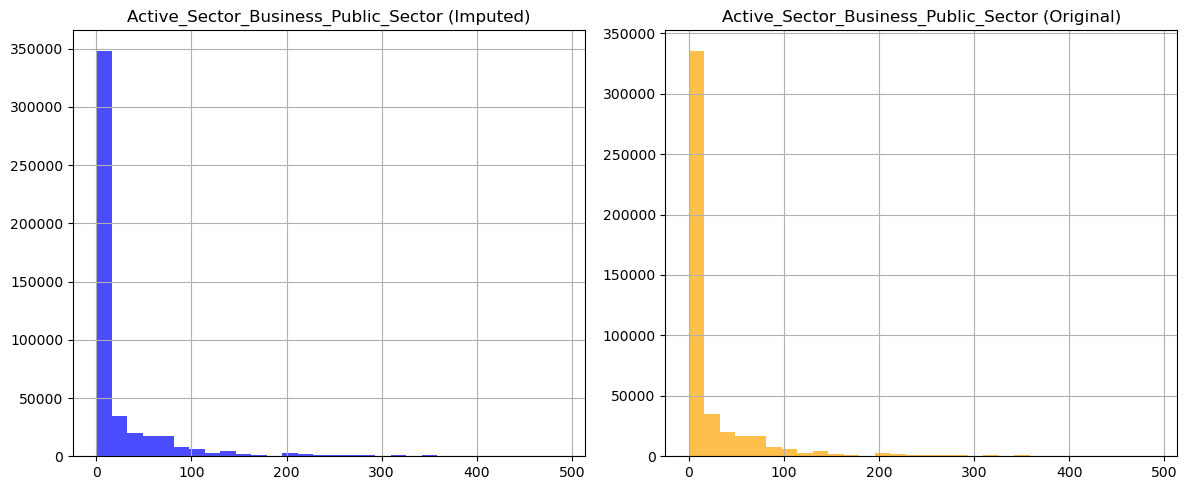

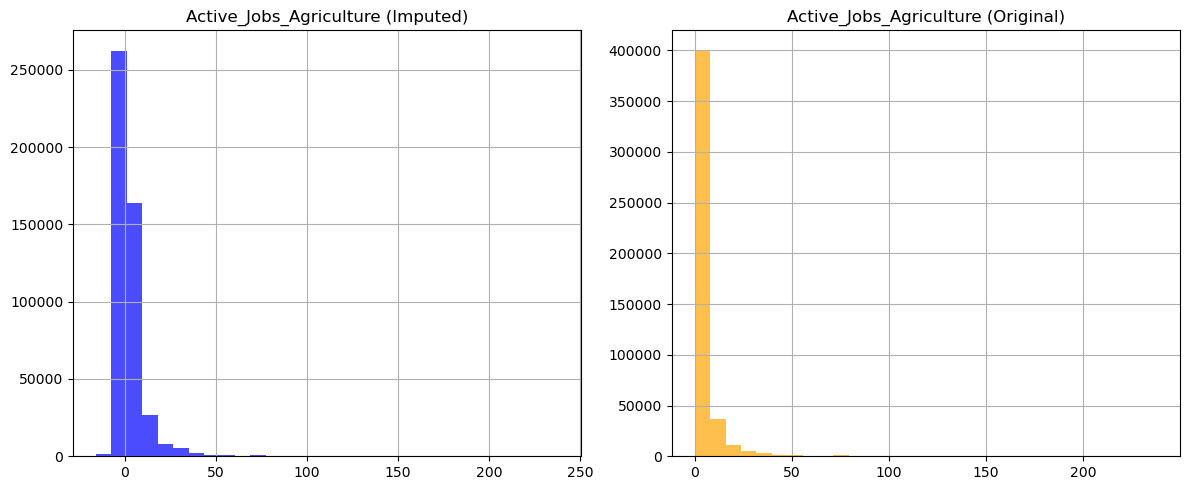

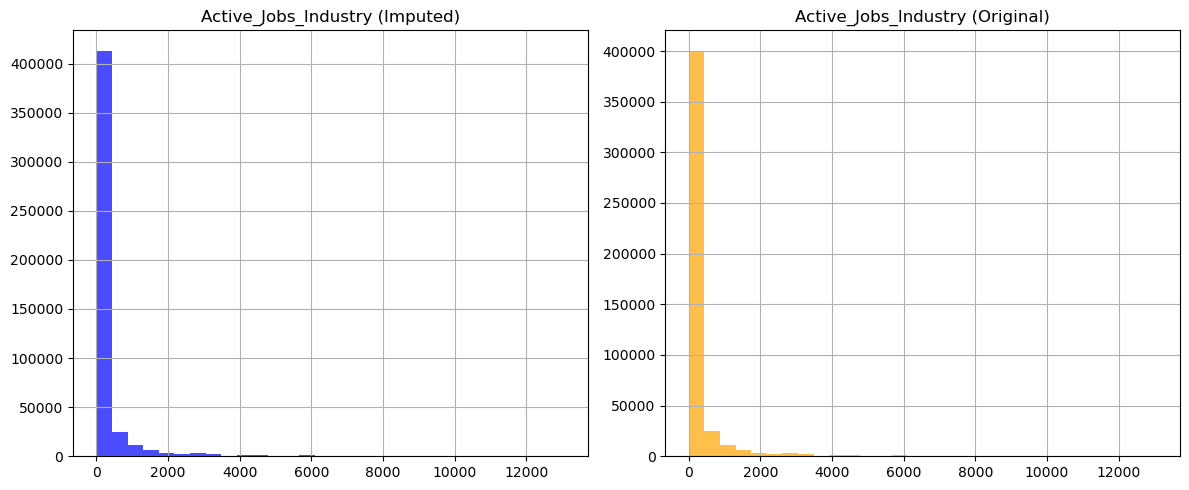

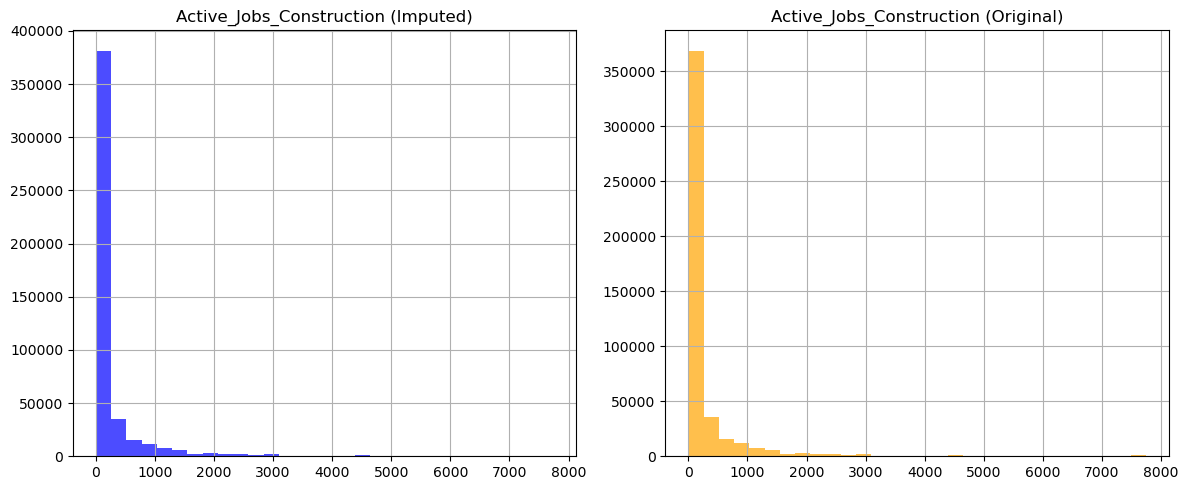

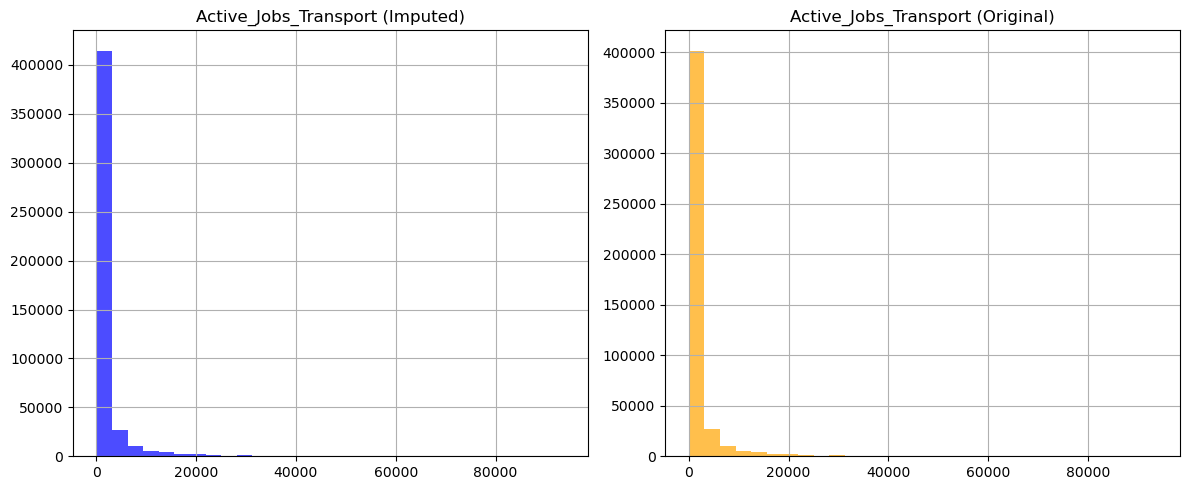

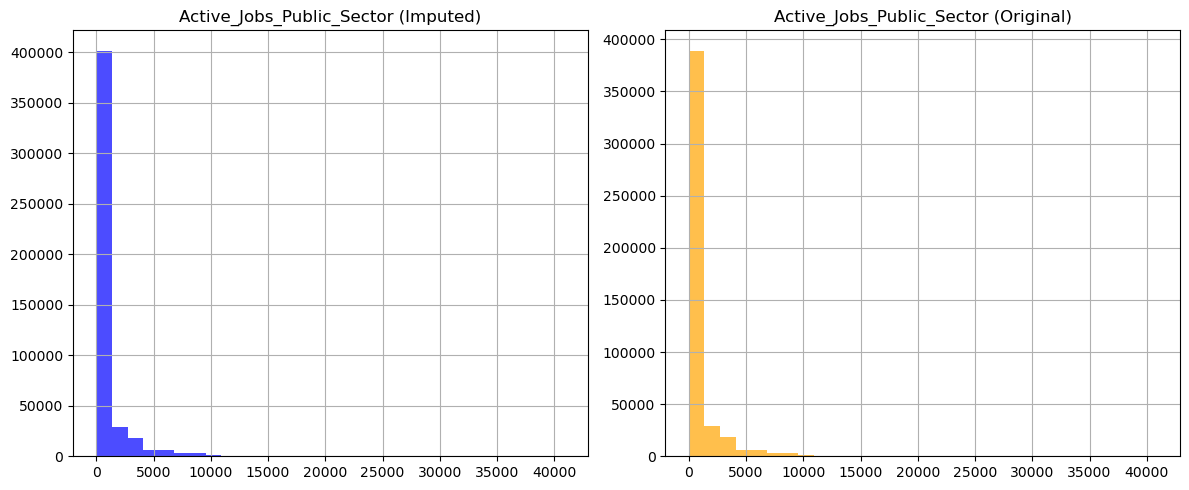

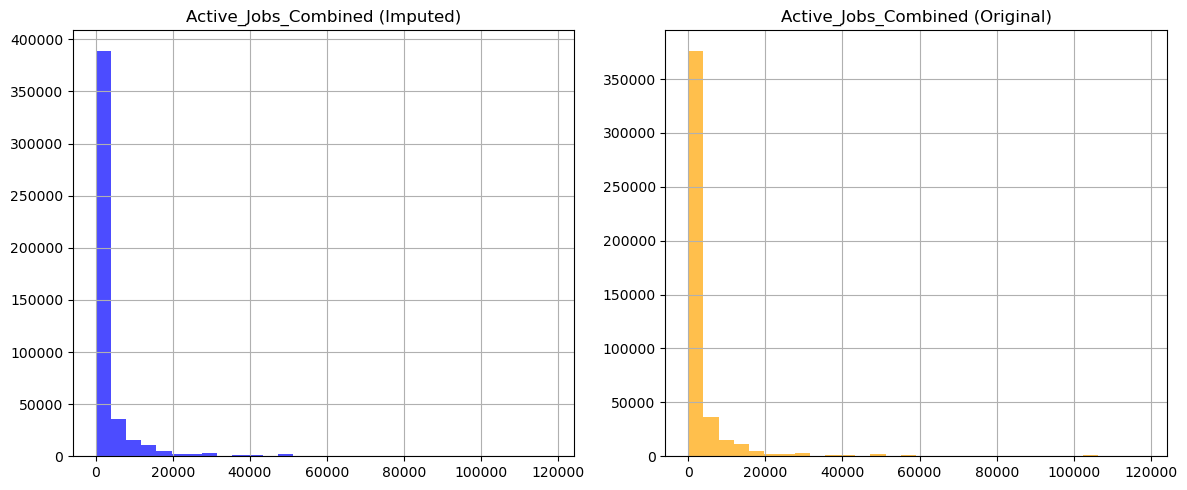

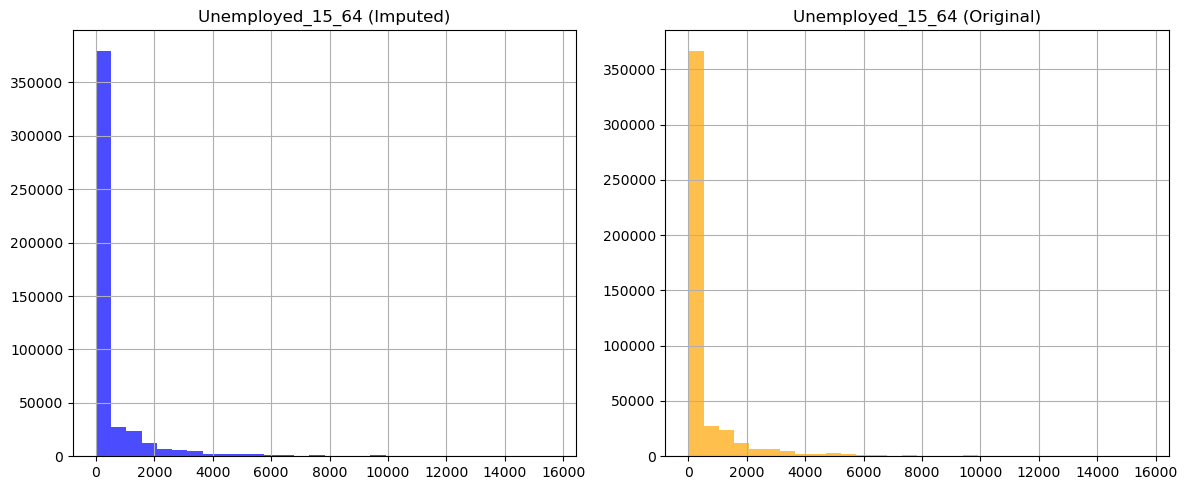

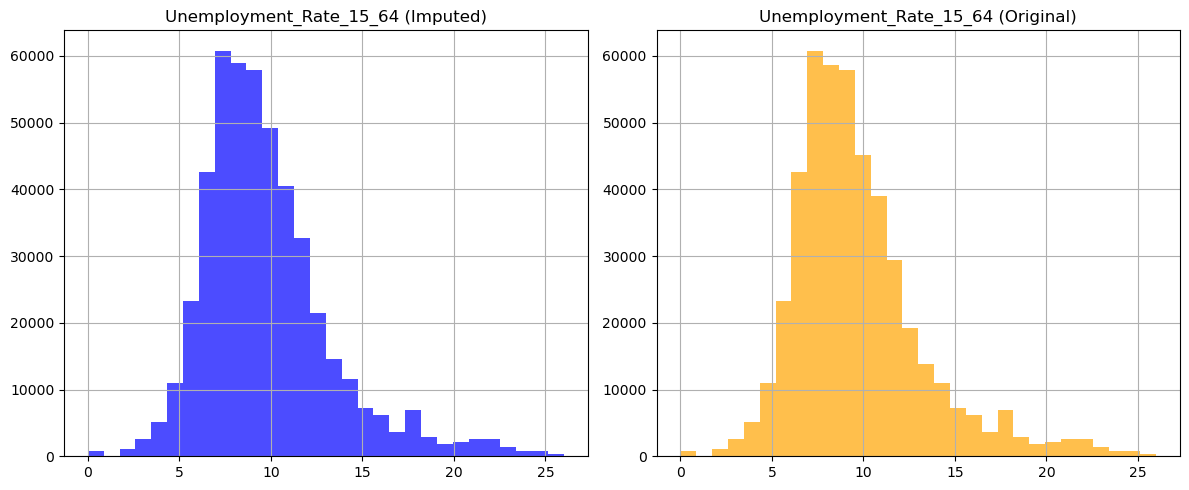

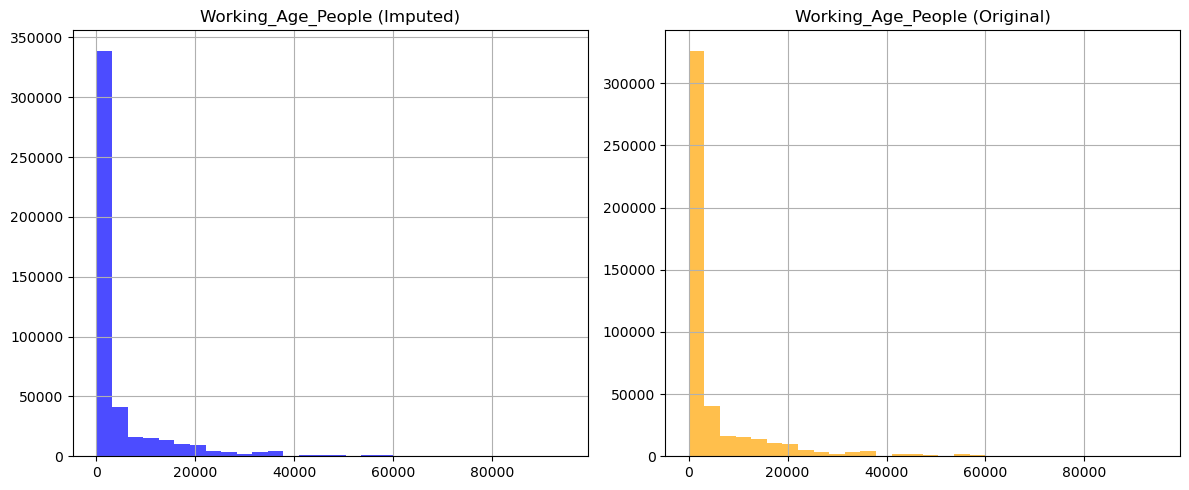

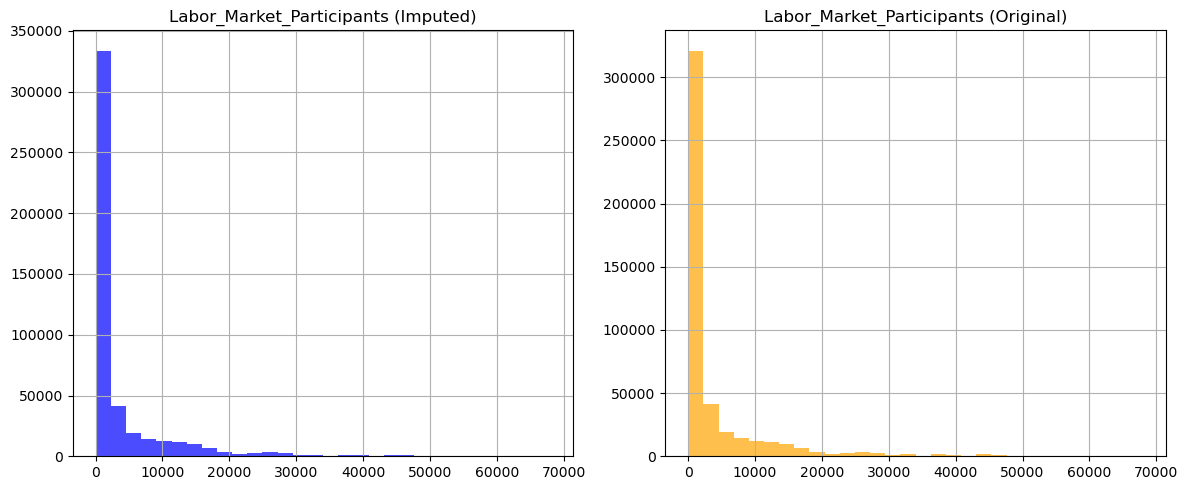

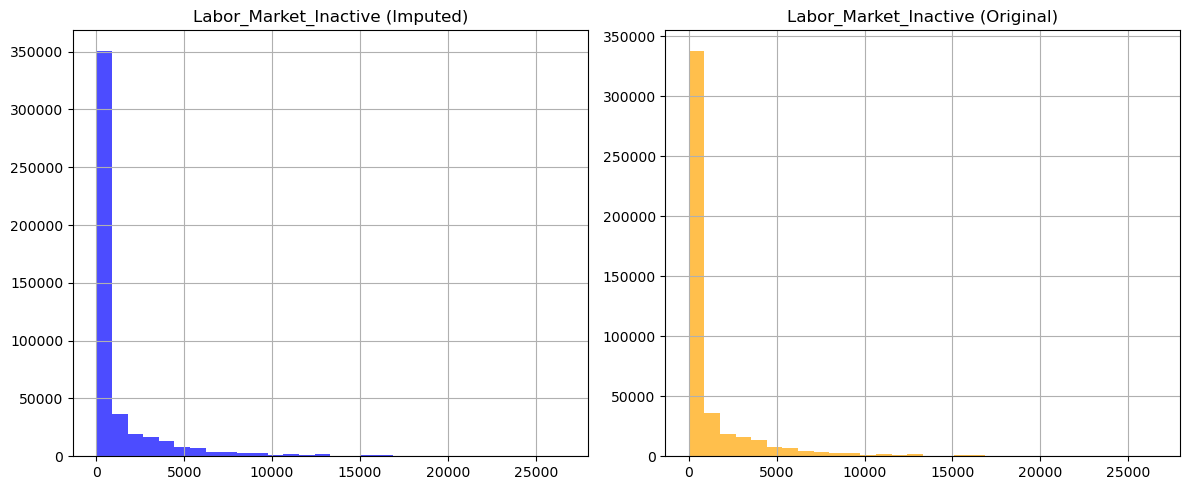

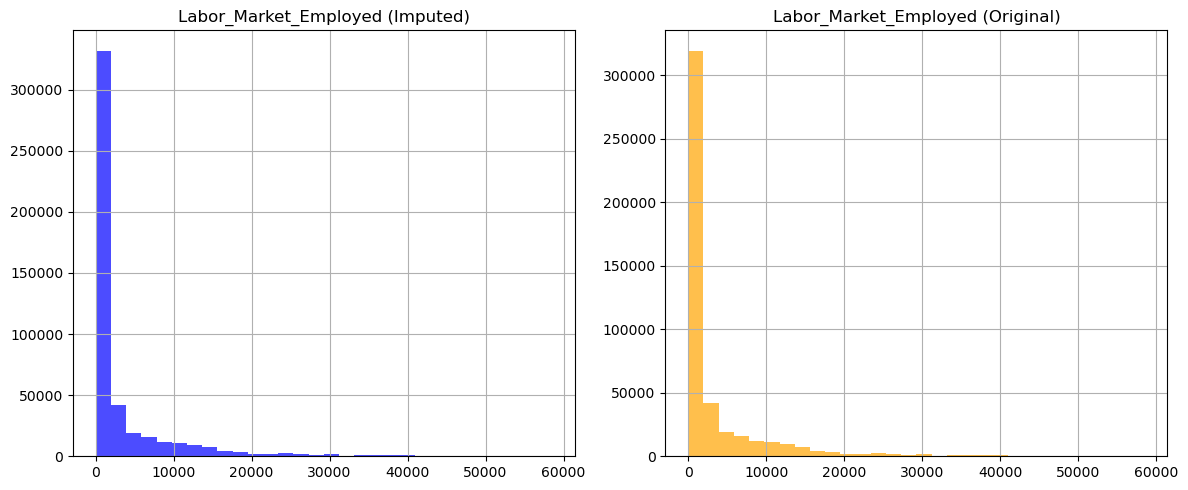

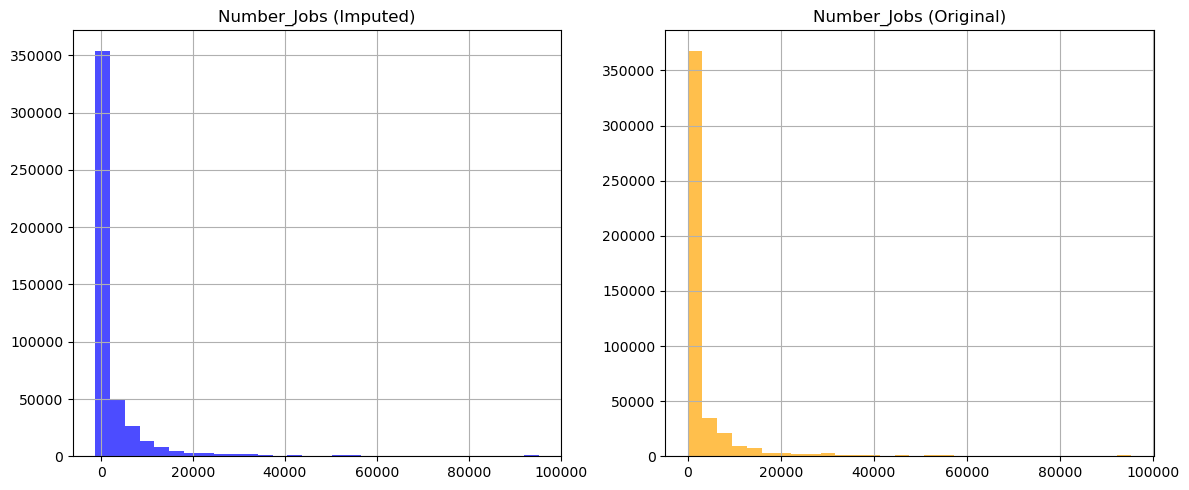

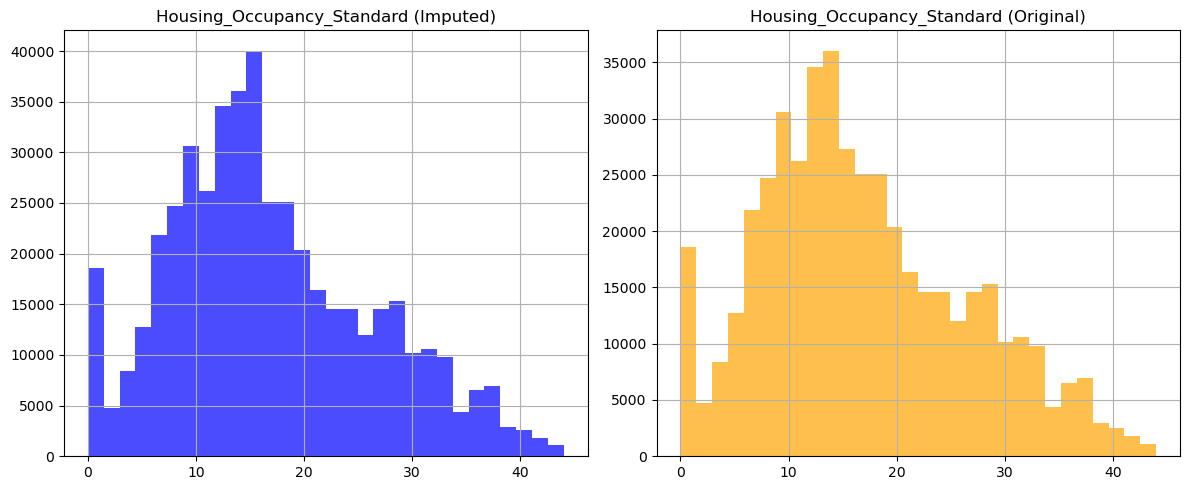

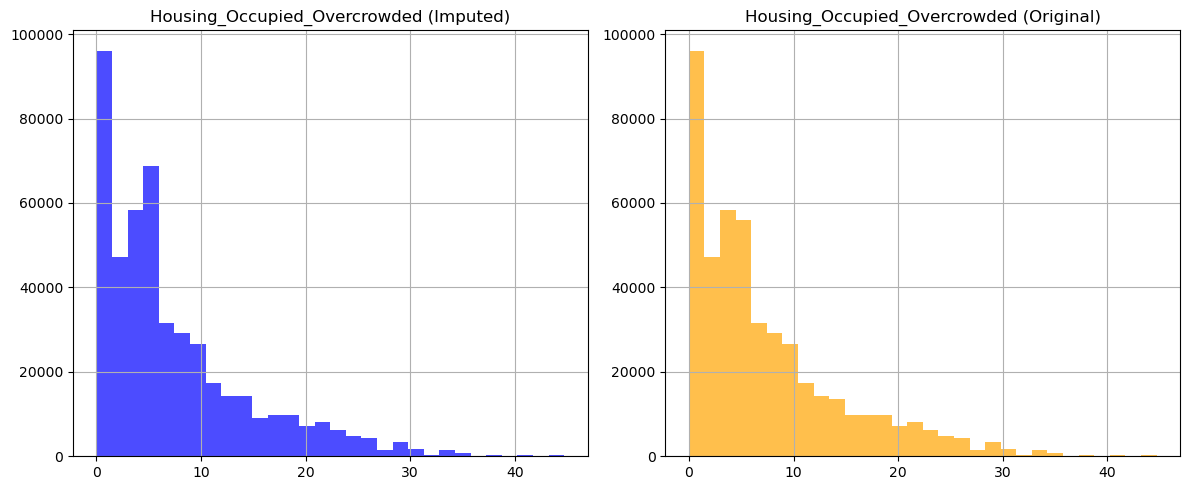

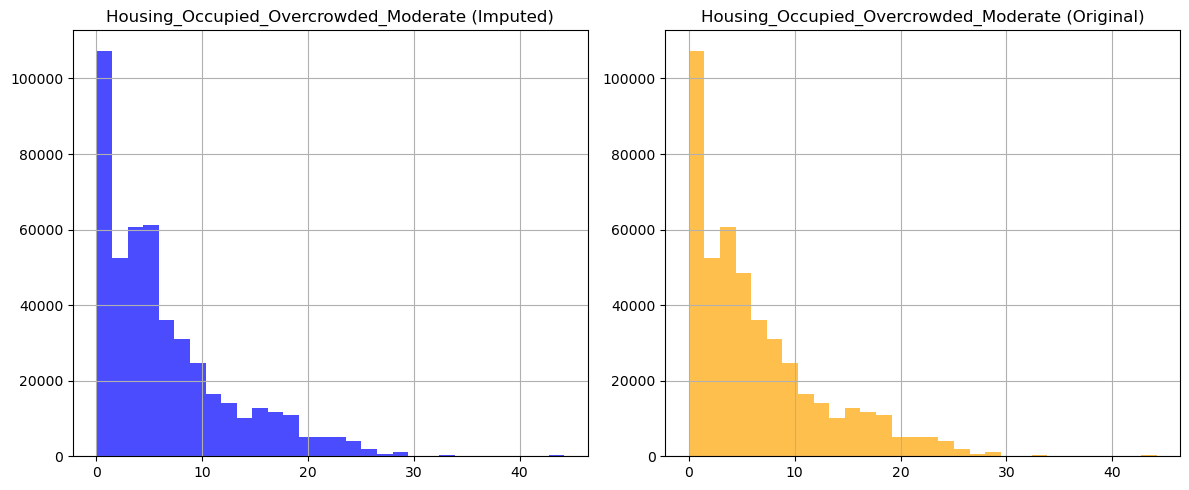

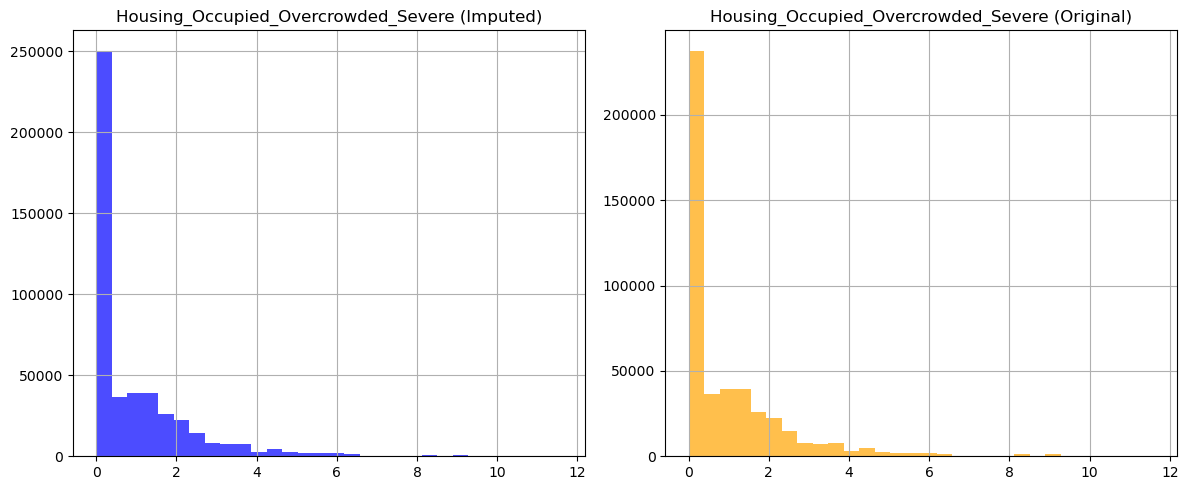

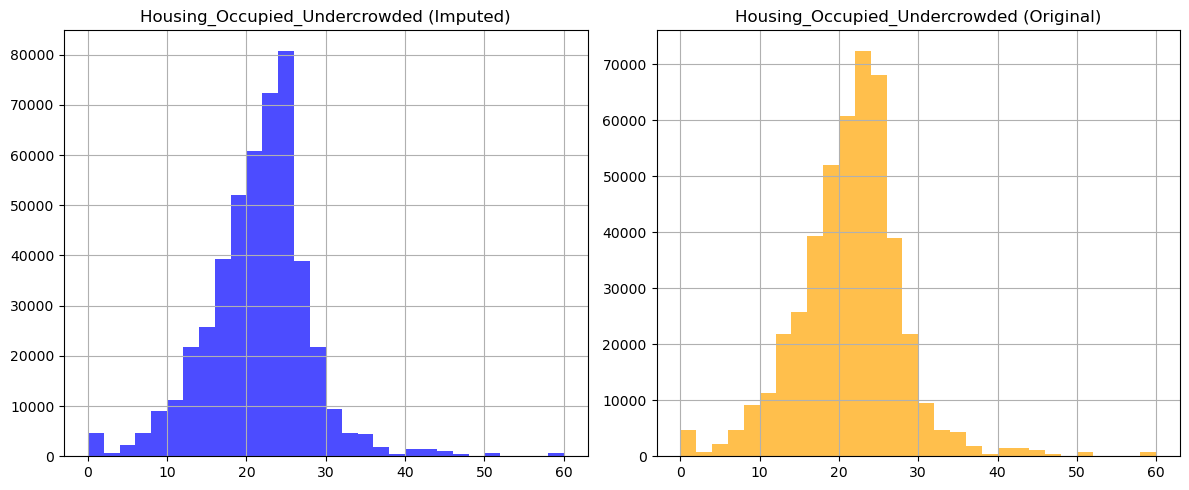

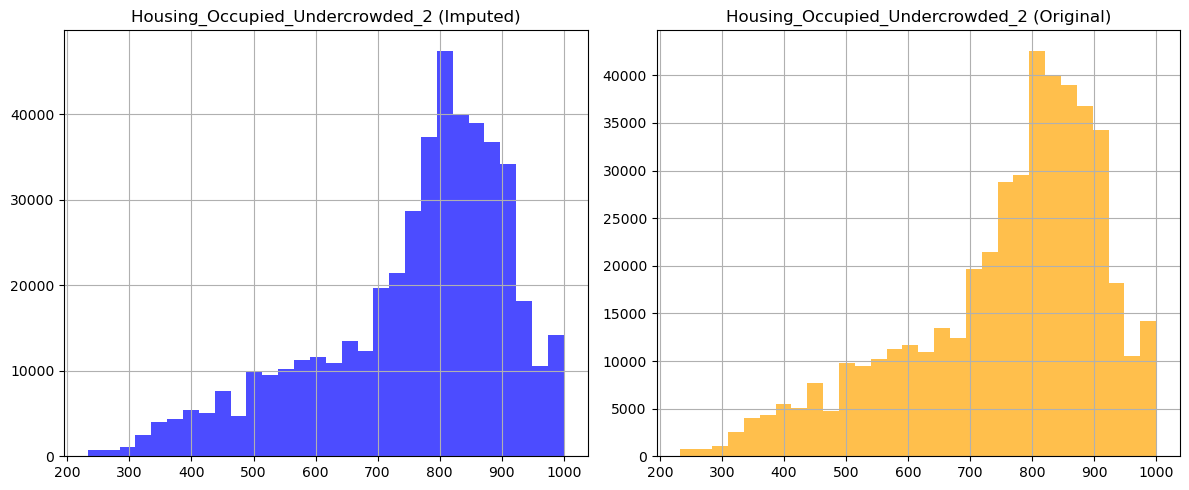

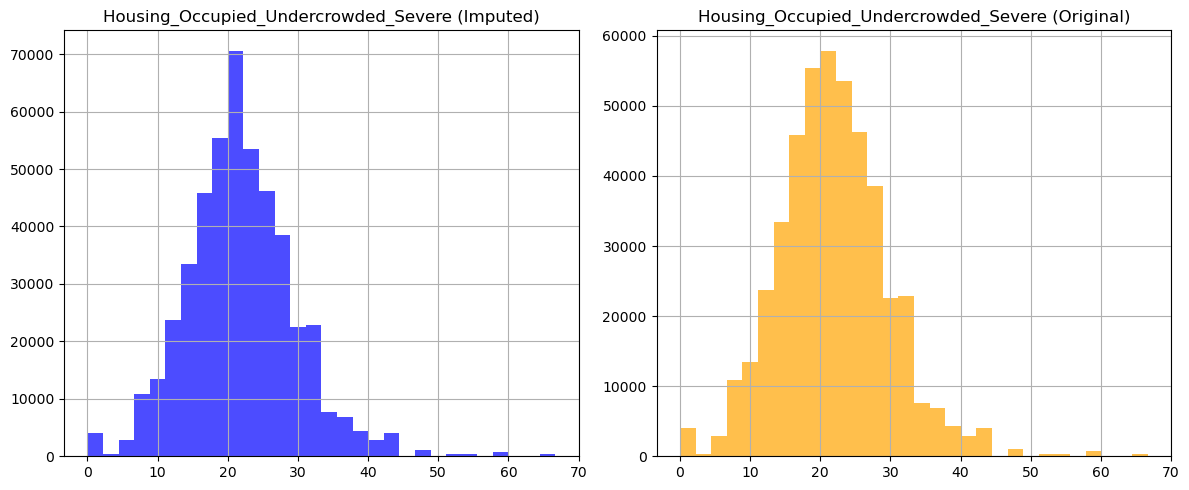

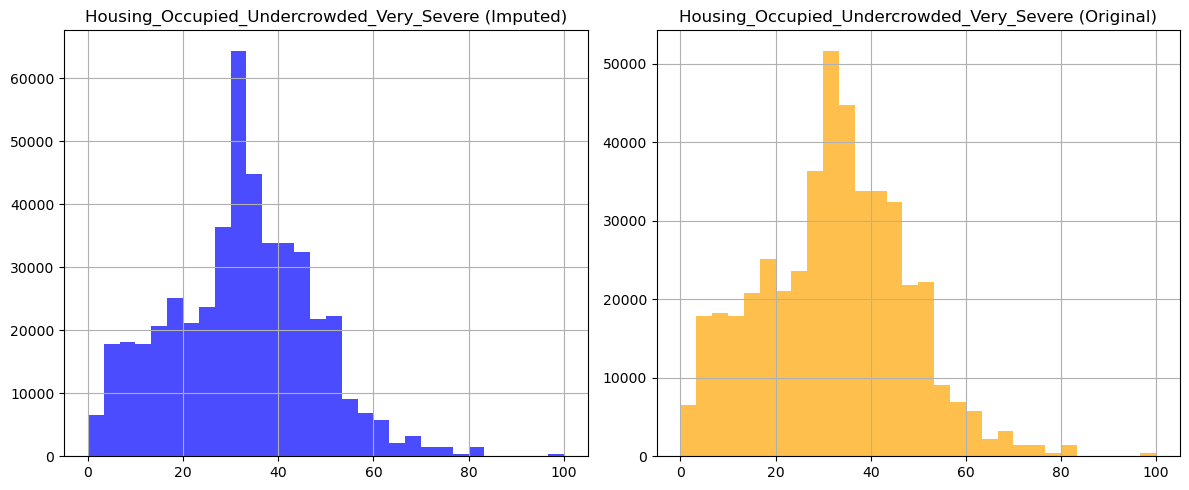

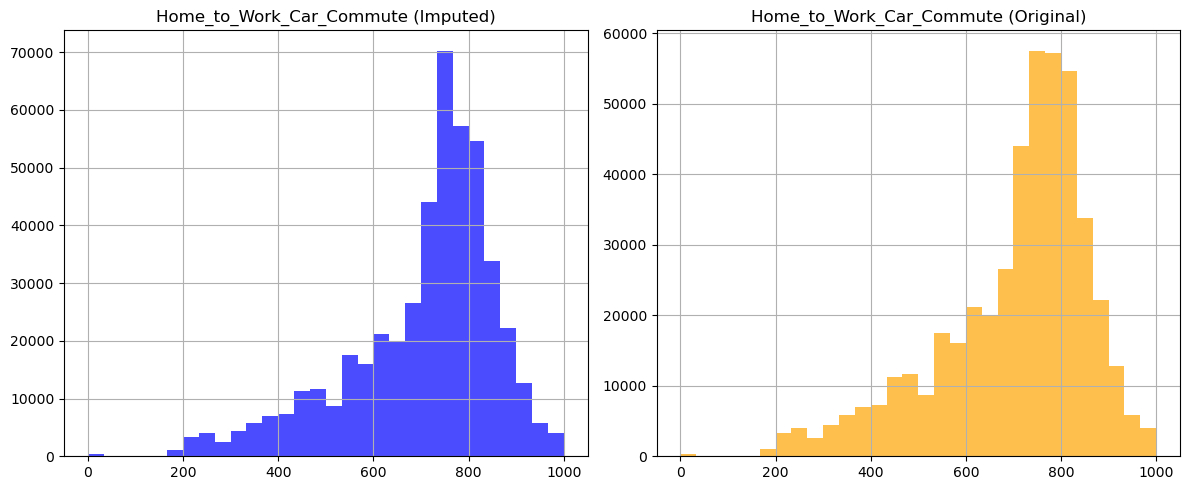

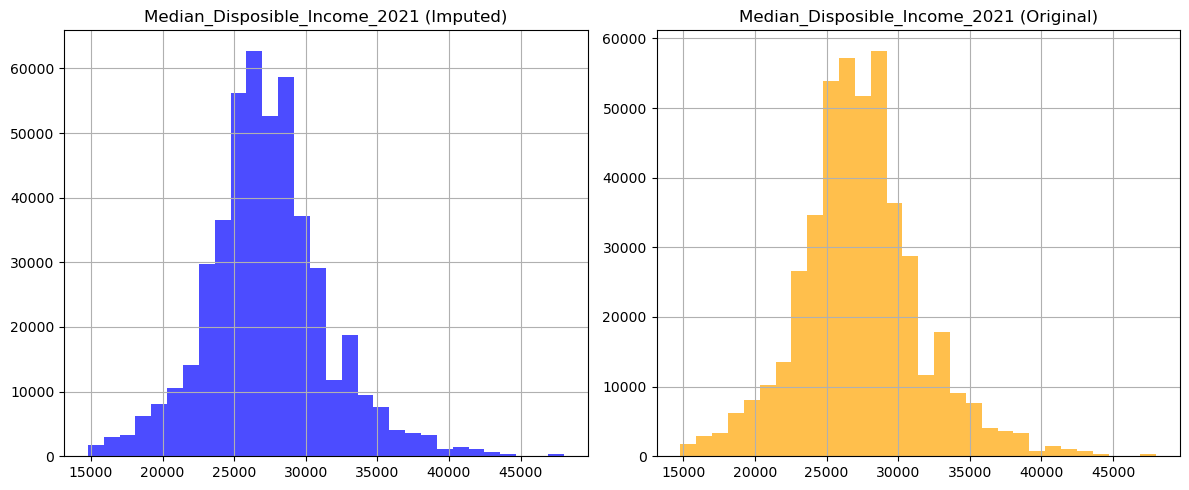

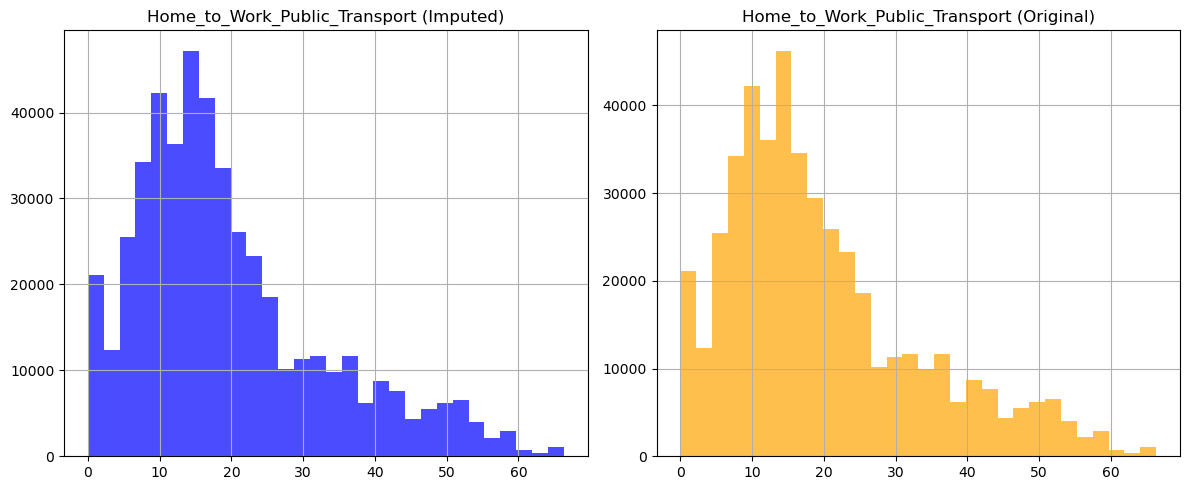

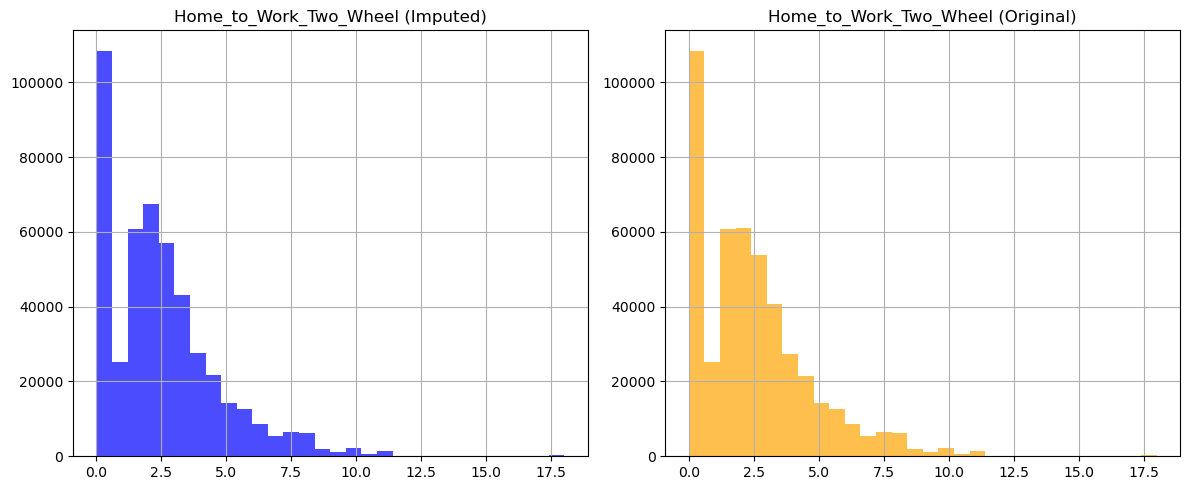

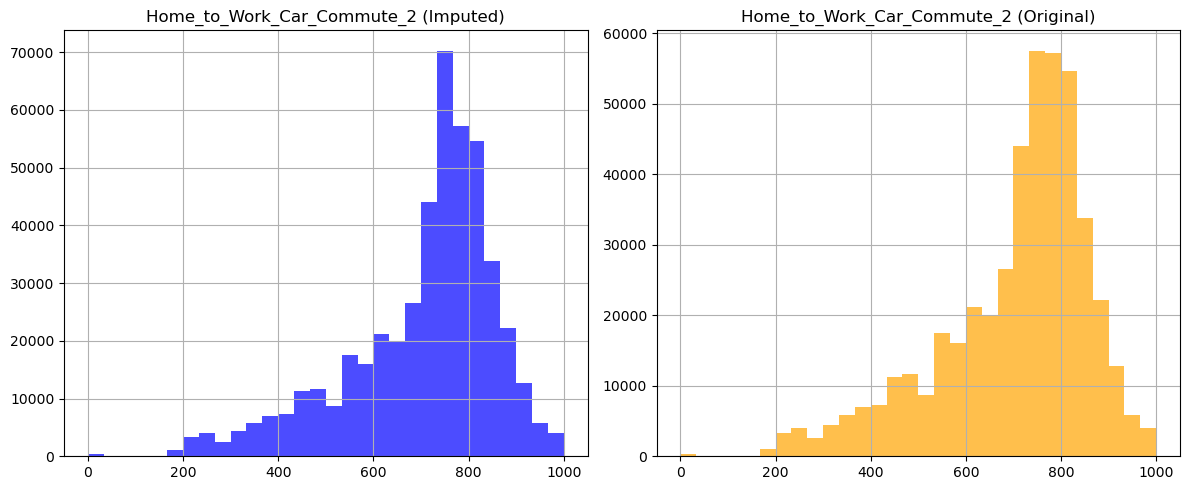

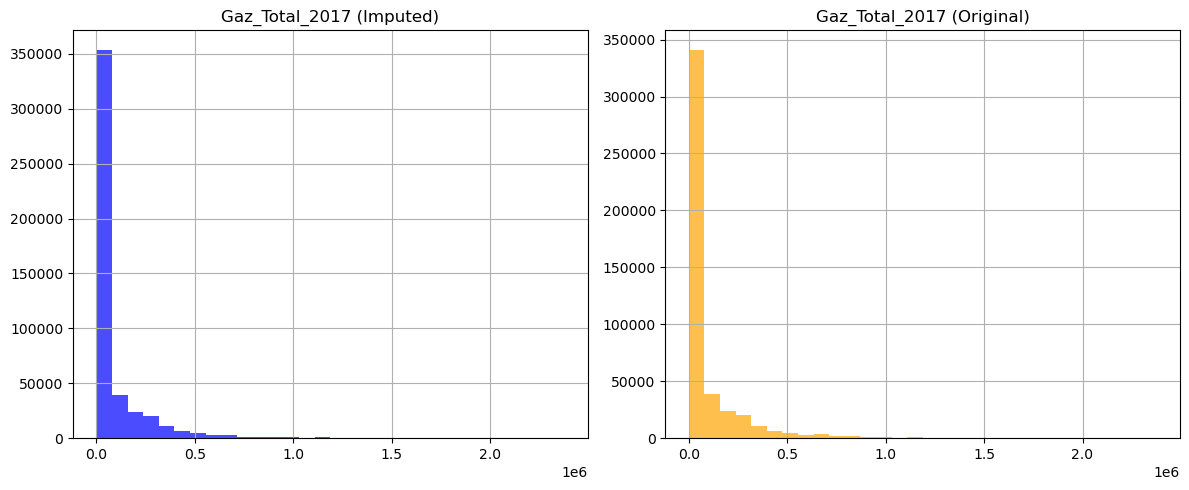

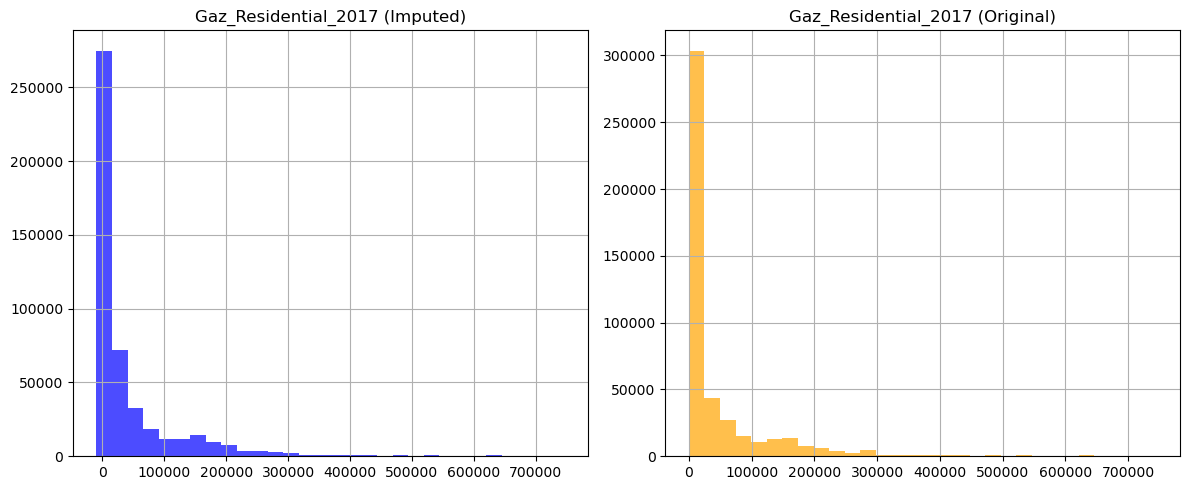

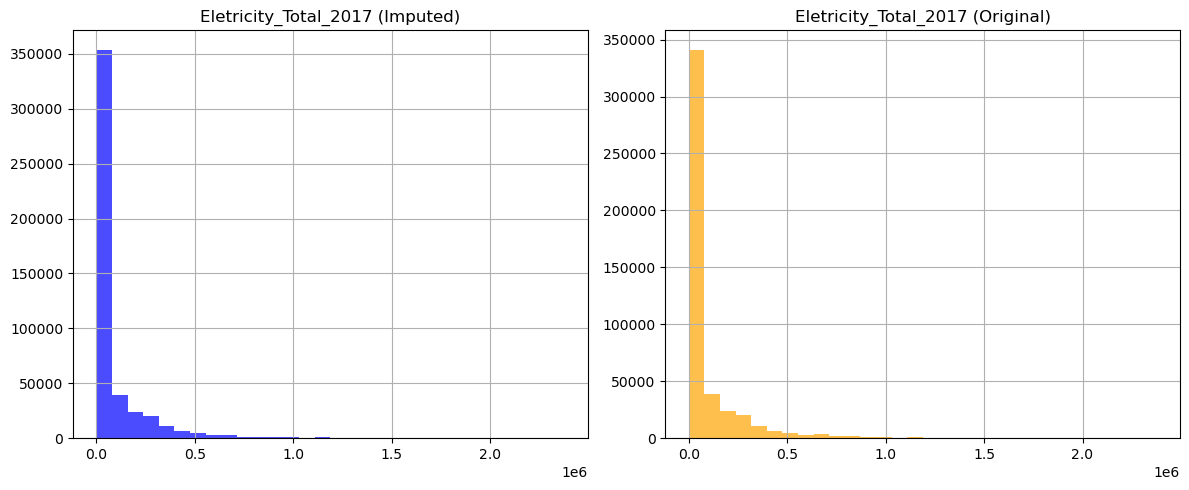

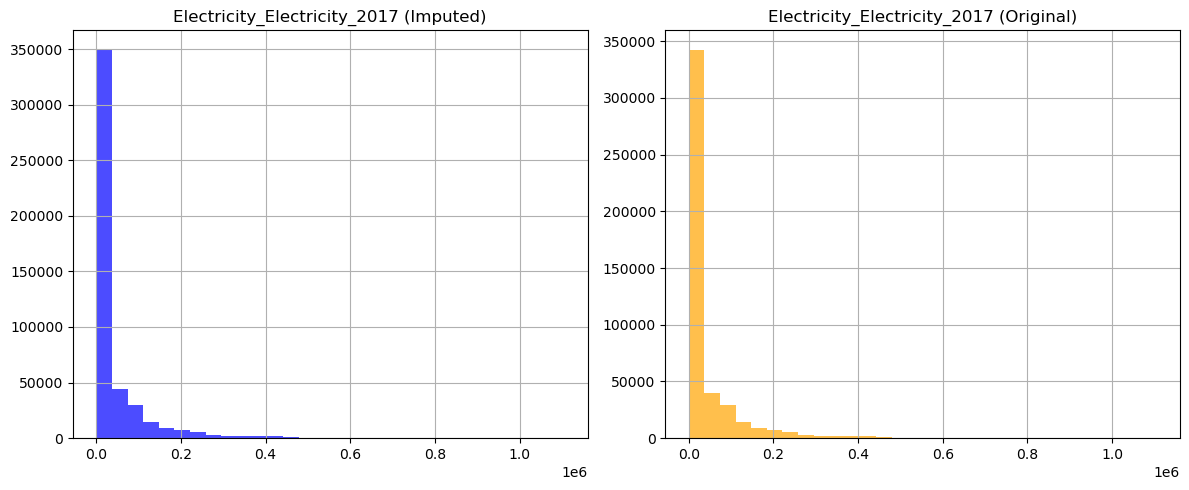

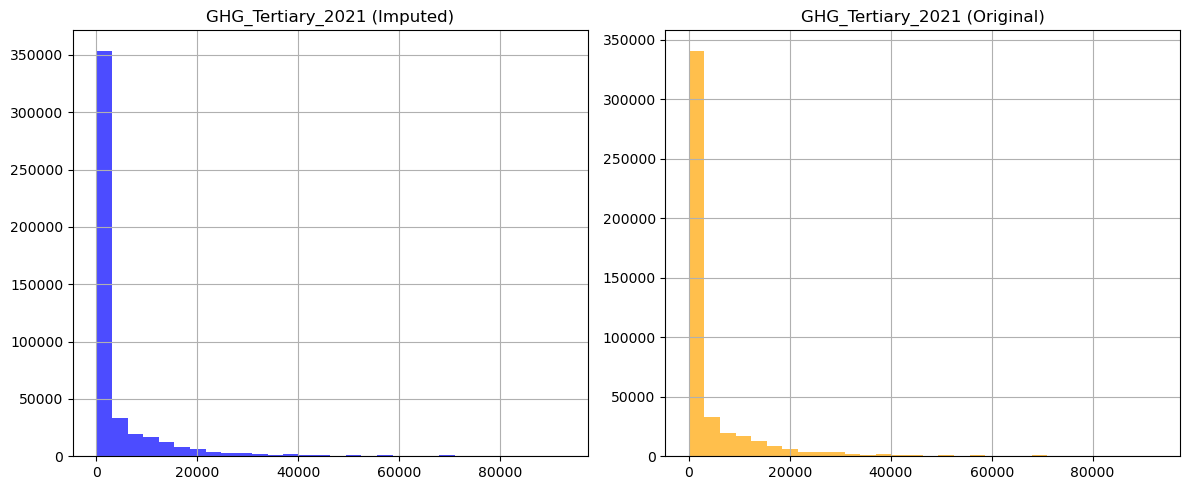

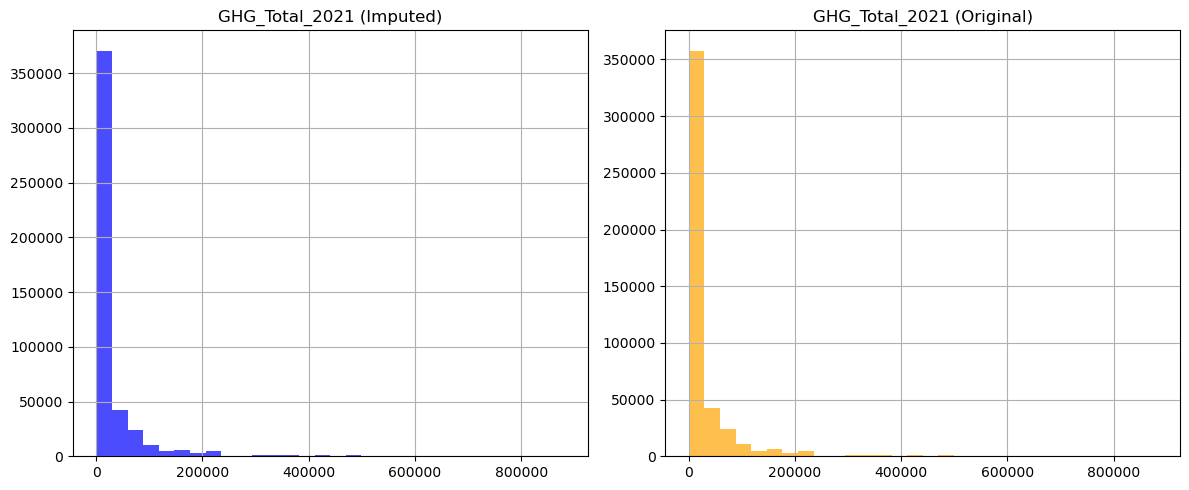

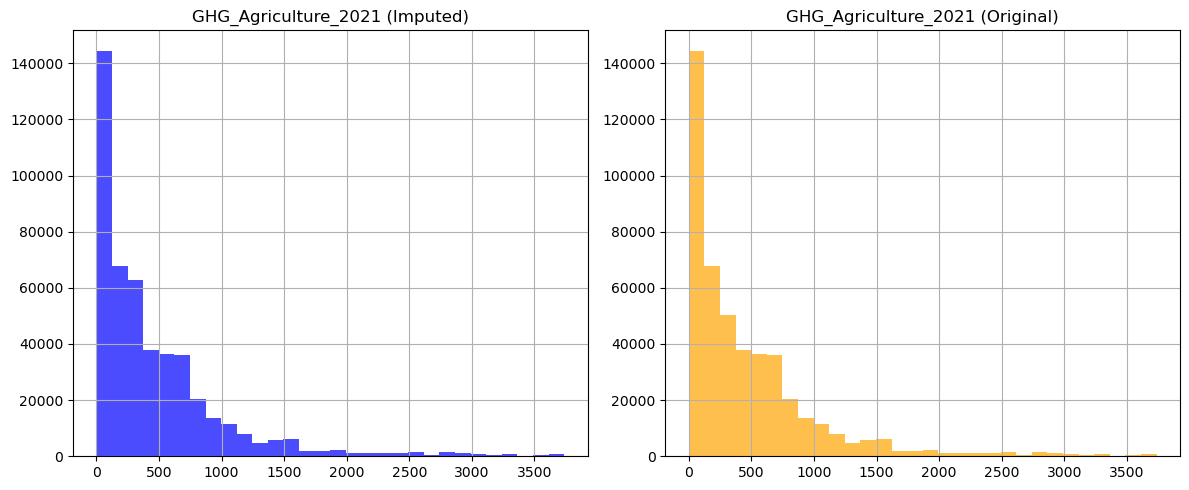

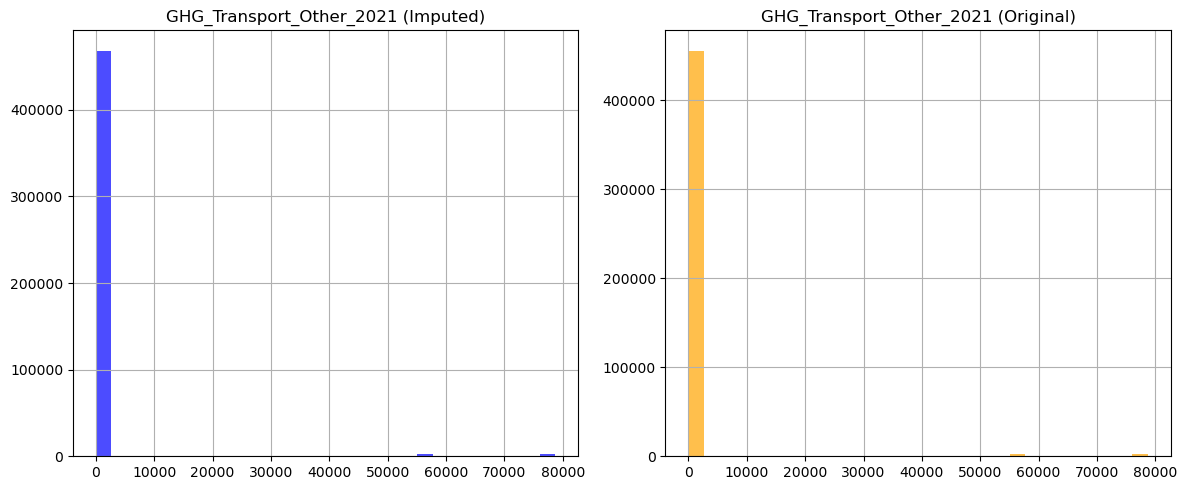

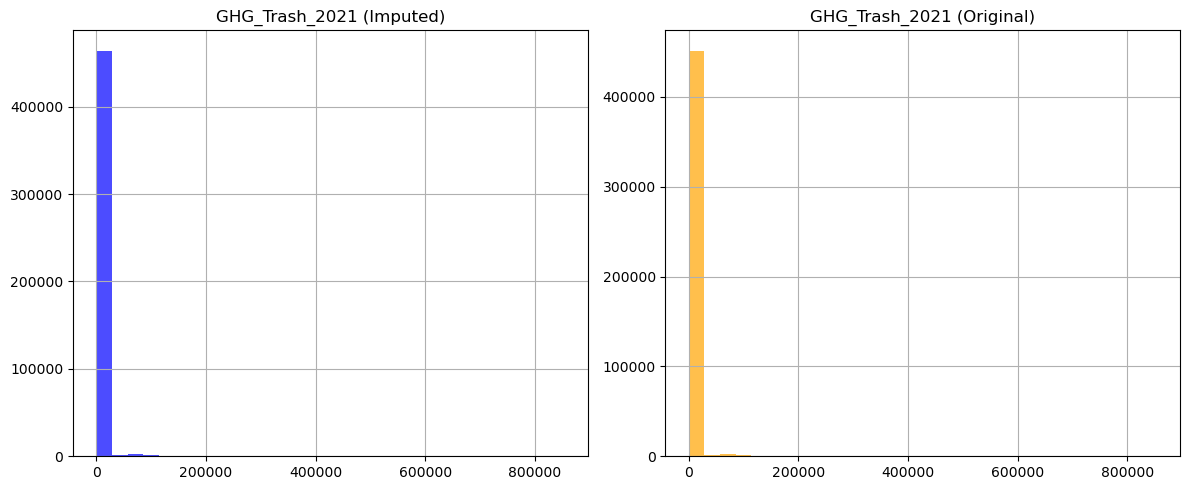

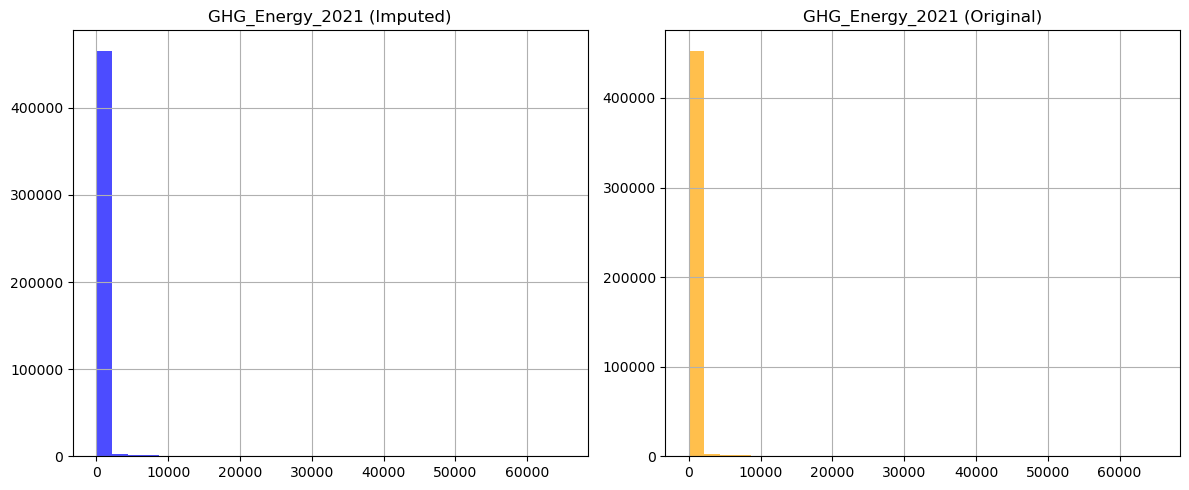

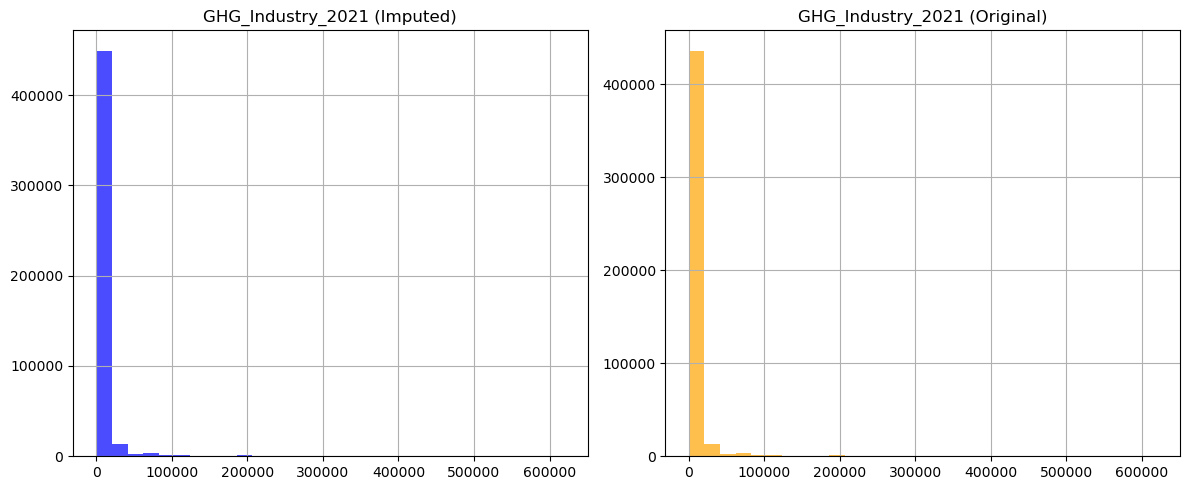

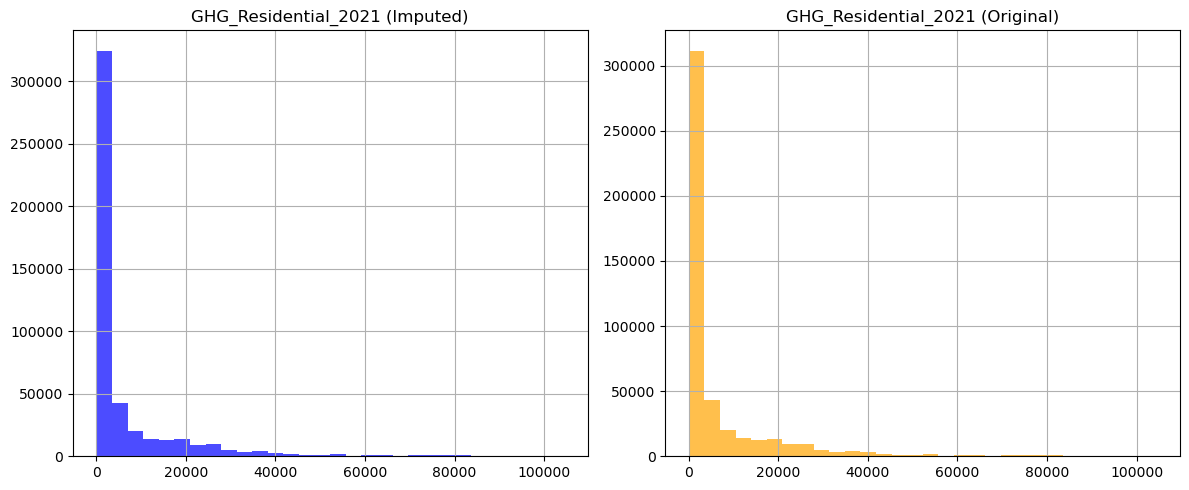

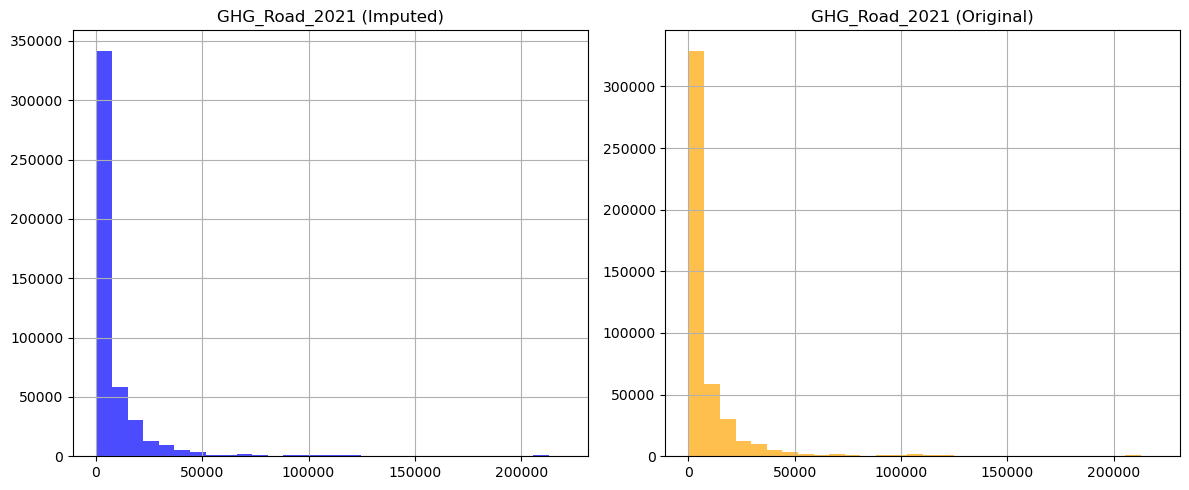

In [36]:
# give the imputed values a quick check by comparing distributions before and after imputation
import matplotlib.pyplot as plt
for col in columns_to_impute:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    df_clean[col].hist(bins=30, alpha=0.7, color='blue')
    plt.title(f"{col} (Imputed)")
    plt.subplot(1, 2, 2)
    df[col].hist(bins=30, alpha=0.7, color='orange')
    plt.title(f"{col} (Original)")
    plt.tight_layout()
    plt.show()